<a href="https://colab.research.google.com/github/armybonita/Good-Energy-Intelligence-Score/blob/main/%EB%94%A5%EB%9F%AC%EB%8B%9D%EC%8B%A4%EC%8A%B5_RNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Part 1: Time-Series Regression via LSTM

본 파트는 시계열(Time-Series) 데이터 내재된 시간적 의존성(Temporal Dependency)을 모델링하기 위해 LSTM(Long Short-Term Memory) 아키텍처를 도입한다.

금융공학적 모델링에서 주가와 같은 비정상성(Non-stationary) 시계열 데이터를 다룰 때, 과거의 Sequence $X = \{x_{t-k}, \dots, x_{t-1}, x_t\}$ 정보를 기반으로 미래의 시점 $x_{t+1}$의 Continuous Value를 예측하는 것은 핵심적인 과제다.

표준 RNN이 지닌 장기 의존성(Long-term Dependencies) 학습의 한계와 기울기 소실(Vanishing Gradient) 문제를 해결하기 위해 도입된 Gating Mechanism의 수학적 구조를 이해하고, 회귀(Regression) 문제의 목적 함수인 $\mathcal{L}_{MSE}$를 최적화하는 전체 파이프라인을 구축한다.

![image](https://snowdeer.github.io/assets/machine-learning/046.png)

## 시계열 데이터셋 수집 및 특성 분석

yfinance API를 활용하여 실제 금융 시장의 주가 데이터를 수집한다.

단변량 시계열(Univariate Time-Series)을 가정하고 종가(Close Price)를 Target Variable로 설정한다.

금융 시계열 데이터는 추세(Trend)와 이분산성(Heteroskedasticity)을 포함하며 높은 노이즈를 동반하므로, 신경망의 입력으로 주입하기 전 데이터의 분포와 스케일을 분석하는 과정이 선행되어야 한다.

In [ ]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

def fetch_and_analyze_financial_data(ticker: str, start_date: str, end_date: str) -> pd.DataFrame:
    """
    지정된 티커의 주가 데이터를 다운로드하고 종가(Close) 데이터를 반환한다.
    """
    df = yf.download(ticker, start=start_date, end=end_date)

    # 데이터 정합성 검증
    if df.empty:
        raise ValueError(f"No data fetched for {ticker}. Check ticker or date range.")
    assert df.isnull().sum().sum() == 0, "Missing values detected in the dataset."

    # 단변량 시계열 분석을 위한 종가 추출
    close_data = df[['Close']].copy()

    return close_data

### 데이터 수집 (종목, 시작일자, 종료일자)

In [ ]:
# 1. 데이터 수집
ticker_symbol = 'AAPL'
start_idx = '2015-01-01'
end_idx = '2026-04-19'

ts_data = fetch_and_analyze_financial_data(ticker_symbol, start_idx, end_idx)

/tmp/ipykernel_19633/3911499138.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed


### 기초 통계량 확인

In [ ]:
# 2. 기초 통계량 확인
print(f"[{ticker_symbol}] Time-Series Data Description:")
print(ts_data.describe())

[AAPL] Time-Series Data Description:
Price         Close
Ticker         AAPL
count   2839.000000
mean     110.183223
std       77.245774
min       20.584808
25%       37.125195
50%      108.552666
75%      171.189995
max      285.922455


### 데이터 시각화 (EDA)

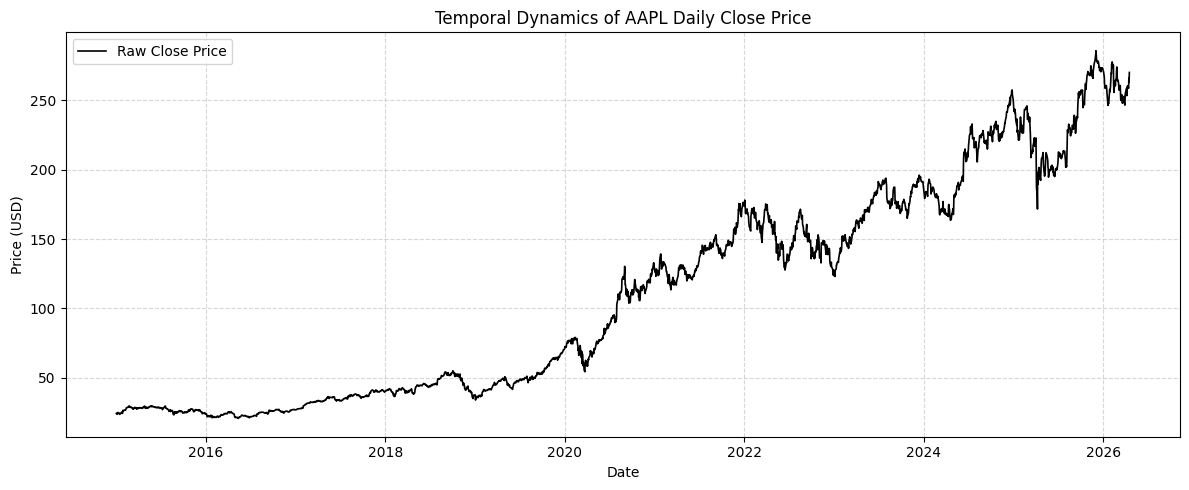

In [ ]:
plt.figure(figsize=(12, 5))
plt.plot(ts_data.index, ts_data['Close'], label='Raw Close Price', color='k', linewidth=1.2)
plt.title(f"Temporal Dynamics of {ticker_symbol} Daily Close Price")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## 시퀀스 데이터 전처리 (Normalization 및 Look-back Window)

신경망, 특히 LSTM과 같은 Gating 메커니즘을 포함하는 순환 신경망 구조는 입력 데이터의 스케일에 극도로 민감하다.

내부적으로 $\sigma(x)$ 및 $\tanh(x)$ 활성화 함수를 통과하므로, 스케일링되지 않은 Raw Data를 주입할 경우 기울기 소실(Vanishing Gradient) 또는 폭발(Exploding Gradient) 현상이 발생하여 $\mathcal{L}_{MSE}$의 최적화가 불가능해진다.

따라서 Min-Max 정규화를 통해 입력 공간을 $[0, 1]$ 또는 $[-1, 1]$로 투영해야 한다.

$$x_{t}^{(norm)} = \frac{x_t - \min(\mathcal{X}_{train})}{\max(\mathcal{X}_{train}) - \min(\mathcal{X}_{train})}$$

또한, 시계열 예측을 지도 학습(Supervised Learning) 문제로 변환하기 위해 슬라이딩 윈도우(Sliding Window) 기법을 적용한다.

Look-back window size를 $W$라 할 때, 특정 시점 $t$의 입력 $X_t$와 정답 레이블 $y_t$는 다음과 같이 정의된다.

$$X_t = [x_{t-W}, x_{t-W+1}, \dots, x_{t-1}], \quad y_t = x_t$$

**주의**: 스케일러(Scaler)를 피팅할 때, 미래 시점의 정보가 과거로 누수되는 Look-ahead Bias를 엄격히 차단해야만 유의미한 딥러닝 모델을 만들 수 있다.

만일 하지 않는 경우 미래 시점을 이미 알고 있는 상태에서 예측을 수행하기 때문에 train 및 test 단계에서는 잘 작동할 수도 있으나, 실제 모델로 활용하기 어렵다.

즉, 정규화 파라미터(min, max)는 오직 Training Set에서만 추출되어야 하며, Test Set은 해당 파라미터를 그대로 적용하여 변환(Transform)만 수행해야 한다.

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from typing import Tuple


def preprocess_time_series(
    df: pd.DataFrame,
    train_ratio: float = 0.8,
    look_back: int = 60
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, MinMaxScaler]:
    """
    Look-ahead Bias를 방지하기 위해 분할 후 정규화를 수행하며,
    Sliding Window 기법을 통해 (N, W, C) 형태의 3D 텐서 입력을 구성한다.
    """
    raw_data = df['Close'].values.reshape(-1, 1)

    # 1. Train-Test Split (Chronological Order)
    split_idx = int(len(raw_data) * train_ratio)
    train_data = raw_data[:split_idx]
    test_data = raw_data[split_idx:]

    # 2. Normalization (Fit strictly on train_data)
    scaler = MinMaxScaler(feature_range=(0, 1))
    train_scaled = scaler.fit_transform(train_data)
    test_scaled = scaler.transform(test_data)

    # 3. Sliding Window Sequence Generation
    def create_sequences(data: np.ndarray, window_size: int) -> Tuple[np.ndarray, np.ndarray]:
        X, y = [], []
        for i in range(len(data) - window_size):
            X.append(data[i : i + window_size, 0])
            y.append(data[i + window_size, 0])
        return np.array(X), np.array(y)

    X_train, y_train = create_sequences(train_scaled, look_back)
    X_test, y_test = create_sequences(test_scaled, look_back)

    # RNN/LSTM 입력 차원(N, W, C)을 맞추기 위한 Reshape (C=1)
    X_train = np.expand_dims(X_train, axis=-1)
    X_test = np.expand_dims(X_test, axis=-1)
    y_train = np.expand_dims(y_train, axis=-1)
    y_test = np.expand_dims(y_test, axis=-1)

    return X_train, y_train, X_test, y_test, scaler

위 코드는 데이터를 Train 과 test 셋으로 나누는 작업을 수행한다.

실제 데이터는 앞선 시각화와 같이 역사적인 종가(close) 데이터만이 존재하므로 MLP와 CNN 실습에서와 같이 입출력이 정의되기 이전이다.

따라서 X와 Y를 수동으로 나누어주는 작업이 수행되어야 한다.



![image](https://www.mdpi.com/remotesensing/remotesensing-13-03328/article_deploy/html/images/remotesensing-13-03328-g003-550.jpg)

In [ ]:
# 실행 로직
WINDOW_SIZE = 60 # 60일의 과거 데이터를 기반으로 1일의 미래 예측

## 변경 가능한 파라미터, 120일, 100일 등 원하는 값으로 설정 가능

X_train_seq, y_train_seq, X_test_seq, y_test_seq, price_scaler = preprocess_time_series(
    ts_data,
    train_ratio=0.8,
    look_back=WINDOW_SIZE
)

print(f"X_train shape: {X_train_seq.shape}") # (N_train, 60, 1)
print(f"y_train shape: {y_train_seq.shape}") # (N_train, 1)
print(f"X_test shape: {X_test_seq.shape}")   # (N_test, 60, 1)
print(f"y_test shape: {y_test_seq.shape}")   # (N_test, 1)

X_train shape: (2211, 60, 1)
y_train shape: (2211, 1)
X_test shape: (508, 60, 1)
y_test shape: (508, 1)


## PyTorch Dataset 및 DataLoader 구축

생성된 3차원 Numpy 배열 형태의 시퀀스 데이터를 PyTorch 기반 신경망의 입력으로 활용하기 위해 torch.utils.data.Dataset 및 DataLoader 객체로 변경한.


시계열 예측에서 시퀀스 내부의 순서(Look-back Window 내의 시간적 의존성)는 엄격히 보존되어야 하나, 학습 시 미니 배치 간의 순서는 상관관계(Correlation)를 끊고 일반화 성능을 높이기 위해 무작위로 섞는 것(Shuffling)이 일반적이다.

단, 검증 및 테스트 데이터셋은 성능 평가의 일관성을 위해 Shuffling을 비활성화한다.

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader

class TimeSeriesDataset(Dataset):
    """
    미니 배치 연산을 위해 Numpy 텐서를 PyTorch Tensor로 변환하고
    인덱싱 인터페이스를 제공하는 Dataset 클래스.
    """
    def __init__(self, X: np.ndarray, y: np.ndarray):
        # 역전파(Backpropagation) 시 가중치 업데이트 연산을 위해 float32 형변환 필수
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self) -> int:
        return len(self.X)

    def __getitem__(self, idx: int) -> tuple:
        return self.X[idx], self.y[idx]

In [ ]:
# 하이퍼파라미터 설정
BATCH_SIZE = 64

# Dataset 인스턴스화
train_dataset = TimeSeriesDataset(X_train_seq, y_train_seq)
test_dataset = TimeSeriesDataset(X_test_seq, y_test_seq)

# DataLoader 구축 (pin_memory=True 설정을 통해 CPU->GPU 데이터 전송 오버헤드 최소화)
train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=True,     # 마지막 배치의 크기가 다를 경우 발생하는 불연속성 방지
    pin_memory=True
)

test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    drop_last=False,
    pin_memory=True
)

In [ ]:
# DataLoader 검증 (Tensor shape 확인)
sample_X, sample_y = next(iter(train_loader))
print(f"Batch X shape: {sample_X.shape}") # Expected: (64, 60, 1) -> (Batch_size, Seq_length, Features)
print(f"Batch y shape: {sample_y.shape}") # Expected: (64, 1)     -> (Batch_size, Target_dim)

Batch X shape: torch.Size([64, 60, 1])
Batch y shape: torch.Size([64, 1])


## LSTM Regression 모델 아키텍처 설계

단일 시점의 Continuous Value를 예측하는 Time-Series Regression은 전형적인 Many-to-One 아키텍처를 요구한다. (입력값 다수 ( 예: 60일), 출력값 하나 (예: 1일))


길이 $W$의 시퀀스 $X \in \mathbb{R}^{B \times W \times C}$ (여기서 $B$는 배치 크기, $C$는 입력 특성 차원)가 입력될 때, LSTM 계층은 각 타임스텝 $t \in [1, W]$에 대해 은닉 상태(Hidden State) $h_t \in \mathbb{R}^{B \times H_{dim}}$를 산출한다.

최종 예측값 $\hat{y} \in \mathbb{R}^{B \times 1}$를 도출하기 위해, 시퀀스의 마지막 타임스텝에서 추출된 은닉 상태 $h_W$를 Fully Connected Layer에 통과시킨다.$$\hat{y} = W_{fc} h_W + b_{fc}$$

설계 시 유의사항:

- Batch First: PyTorch nn.LSTM의 기본 입력 차원은 $(W, B, C)$이다. 1-3에서 구축한 DataLoader의 텐서 형상 $(B, W, C)$과 일치시키기 위해 batch_first=True 인자가 필수적이다.

- Regularization: 금융 시계열 데이터의 높은 노이즈 특성으로 인한 Overfitting을 억제하기 위해, num_layers가 2 이상일 경우 LSTM 계층 간 Dropout을 적용해야 한다.

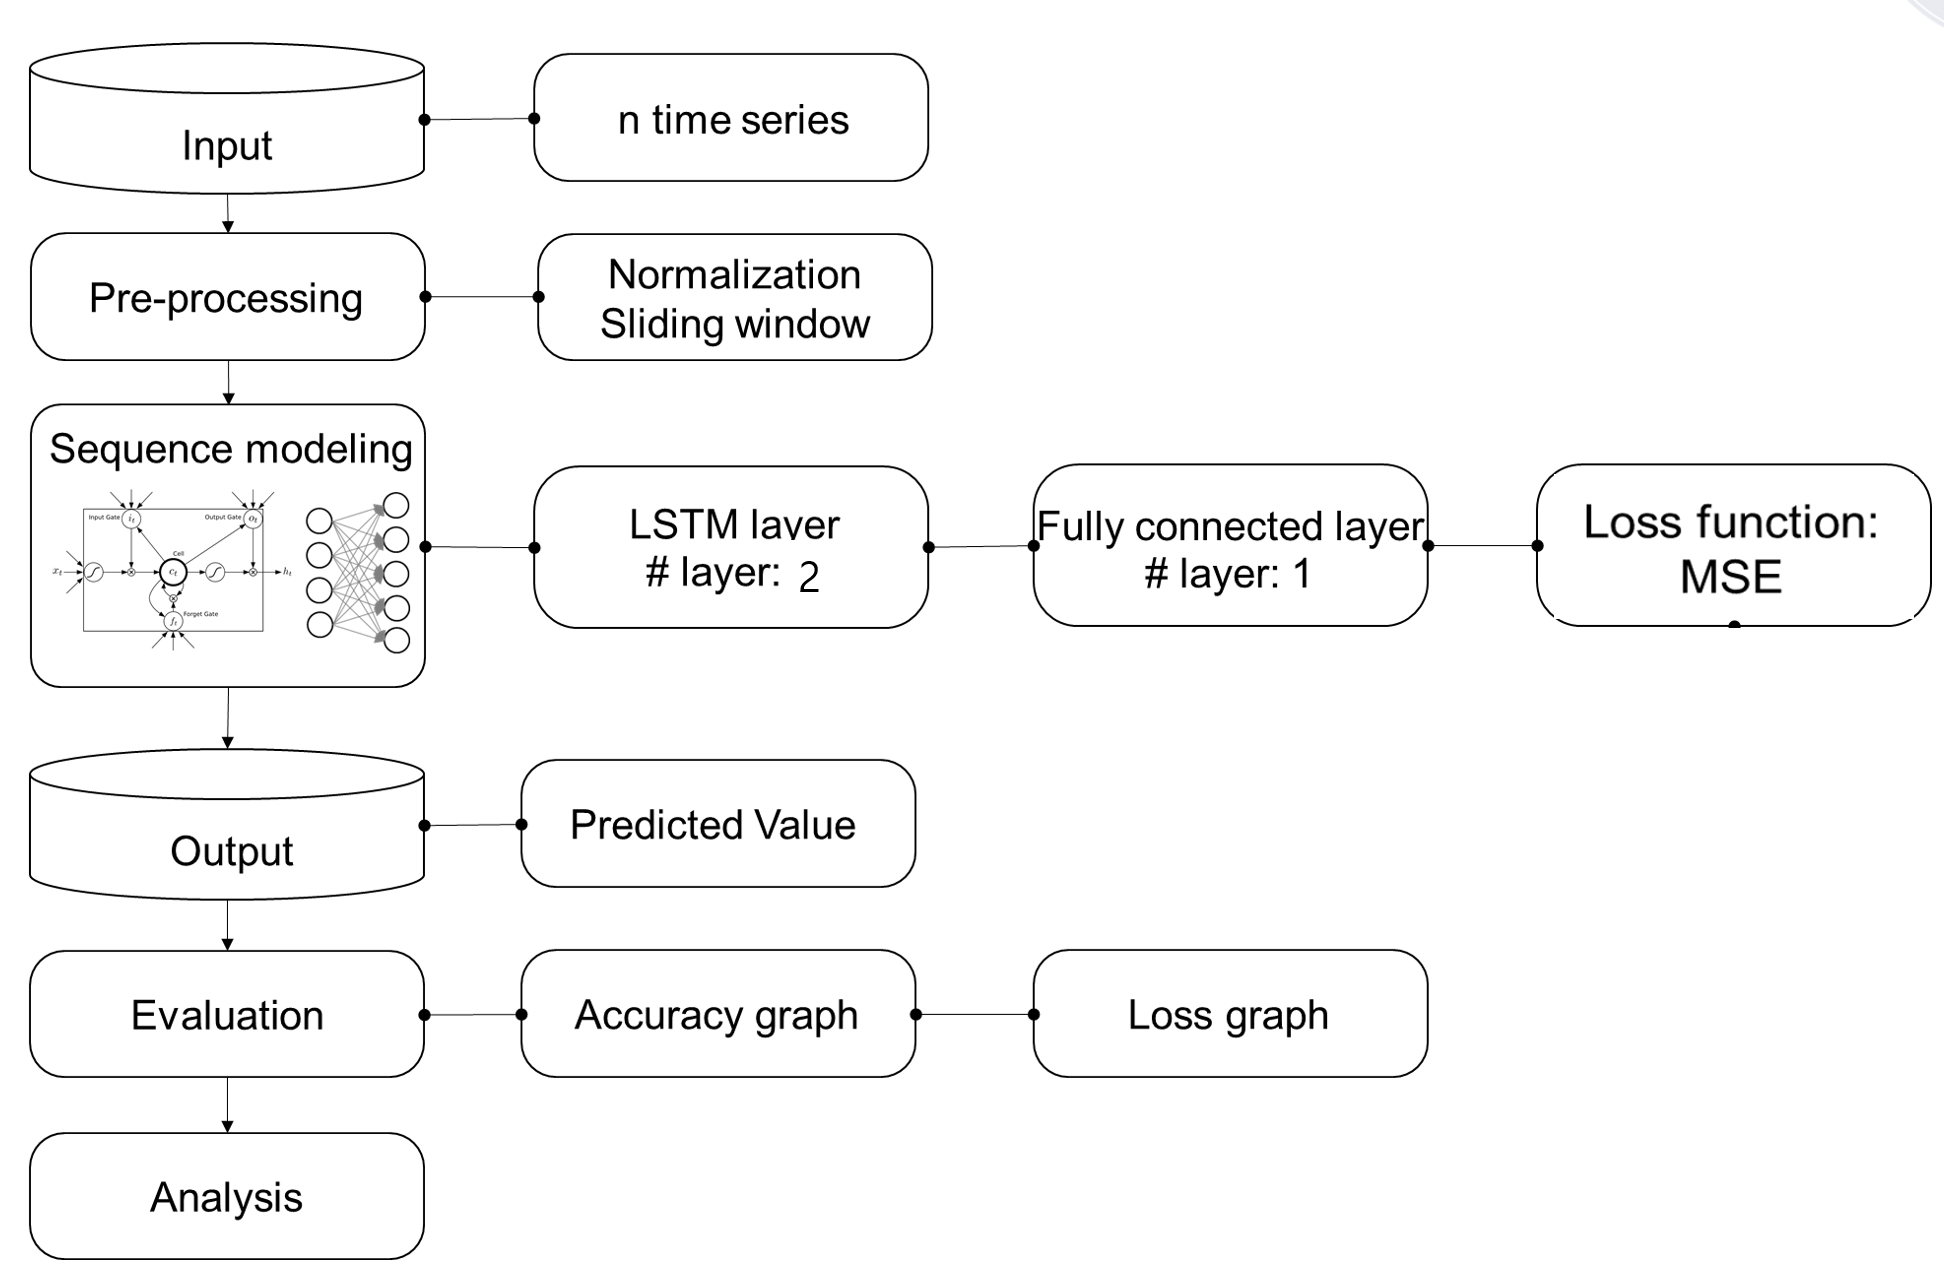

In [ ]:
import torch
import torch.nn as nn

class LSTMRegressor(nn.Module):
    """
    Many-to-One 아키텍처 기반의 LSTM Regression 모델.
    단변량 및 다변량 시계열의 연속형 변수 예측을 수행한다.
    """
    def __init__(self, input_size: int = 1, hidden_size: int = 64, num_layers: int = 2, dropout: float = 0.2): ## LSTM의 레이어는 직접 설정하거나 아래에서 구현하는 것이 아닌, pytorch 내장 함수로 바로 적용 가능
        super(LSTMRegressor, self).__init__()

        self.hidden_size = hidden_size
        self.num_layers = num_layers

        # LSTM Layer
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )

        # Fully Connected Layer for Continuous Value Prediction
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x (torch.Tensor): Input tensor of shape (B, W, C)
        Returns:
            torch.Tensor: Output tensor of shape (B, 1)
        """
        # 은닉 상태(h_0)와 셀 상태(c_0)는 0으로 자동 초기화됨 (기본값)
        # out shape: (B, W, H_dim)
        out, _ = self.lstm(x)

        # Many-to-One: 시퀀스의 마지막 타임스텝(t=W)의 Hidden State 추출
        last_hidden_state = out[:, -1, :]  # shape: (B, H_dim)

        # 선형 변환을 통한 최종 예측값 산출
        predictions = self.fc(last_hidden_state)  # shape: (B, 1)

        return predictions

## 학습 루프 구현 및 $\mathcal{L}_{MSE}$ 최적화 시각화 (RNN vs. LSTM 비교 분석)

최적화 목적 함수로는 $\mathcal{L}_{MSE}$

금융 시계열의 장기 의존성(Long-term Dependency) 학습 성능을 비교하기 위해 Gating 메커니즘이 배제된 표준 RNN(Vanilla RNN) 아키텍처와 비교

시퀀스 길이가 60($W=60$)에 달할 때 표준 RNN에서 발생하는 기울기 소실(Vanishing Gradient) 현상을 확인한다.

### Vanilla RNN 아키텍처 정의 (비교군)

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np


class RNNRegressor(nn.Module):
    def __init__(self, input_size: int = 1, hidden_size: int = 64, num_layers: int = 2, dropout: float = 0.2):
        super(RNNRegressor, self).__init__()
        self.rnn = nn.RNN(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout
        )
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        out, _ = self.rnn(x)
        last_hidden_state = out[:, -1, :]
        return self.fc(last_hidden_state)

### 하드웨어 가속기 설정 및 모델 인스턴스화

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')
print(f"Target execution device: {device}")

# 동일한 파라미터 조건(Hidden=64, Layers=2)으로 두 모델 초기화
lstm_model = LSTMRegressor(input_size=1, hidden_size=64, num_layers=2, dropout=0.2).to(device) ## 모델 구조는 여기서 변경 가능
rnn_model = RNNRegressor(input_size=1, hidden_size=64, num_layers=2, dropout=0.2).to(device)

criterion = nn.MSELoss()
# 최적화 기법: Adam (Weight Decay를 통한 정규화 추가 가능)
lstm_optimizer = optim.Adam(lstm_model.parameters(), lr=1e-3) ## training 파라미터는 여기서 변경 가능
rnn_optimizer = optim.Adam(rnn_model.parameters(), lr=1e-3)

Target execution device: cuda


### 범용 학습 및 검증 파이프라인

In [ ]:
def train_and_evaluate(
    model: nn.Module,
    optimizer: optim.Optimizer,
    train_loader: DataLoader,
    test_loader: DataLoader,
    epochs: int = 50
) -> dict:
    history = {'train_loss': [], 'test_loss': []}

    for epoch in range(epochs):
        # Training Phase
        model.train()
        train_loss_accum = 0.0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            optimizer.zero_grad()
            predictions = model(X_batch)
            loss = criterion(predictions, y_batch)
            loss.backward()

            # Gradient Clipping (Exploding Gradient 억제)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            train_loss_accum += loss.item() * X_batch.size(0)

        epoch_train_loss = train_loss_accum / len(train_loader.dataset)
        history['train_loss'].append(epoch_train_loss)

        # Validation Phase
        model.eval()
        test_loss_accum = 0.0
        with torch.no_grad():
            for X_batch, y_batch in test_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                predictions = model(X_batch)
                loss = criterion(predictions, y_batch)
                test_loss_accum += loss.item() * X_batch.size(0)

        epoch_test_loss = test_loss_accum / len(test_loader.dataset)
        history['test_loss'].append(epoch_test_loss)

        if (epoch + 1) % 10 == 0:
            print(f"Epoch [{epoch+1}/{epochs}] | Train loss: {epoch_train_loss:.4f} | Test loss: {epoch_test_loss:.4f}")

    return history

### 모델 학습 실행

In [ ]:
EPOCHS = 50
print("--- Training LSTM Model ---")
lstm_history = train_and_evaluate(lstm_model, lstm_optimizer, train_loader, test_loader, epochs=EPOCHS)

print("\n--- Training Vanilla RNN Model ---")
rnn_history = train_and_evaluate(rnn_model, rnn_optimizer, train_loader, test_loader, epochs=EPOCHS)

--- Training LSTM Model ---
Epoch [10/50] | Train loss: 0.0008 | Test loss: 0.0093
Epoch [20/50] | Train loss: 0.0006 | Test loss: 0.0052
Epoch [30/50] | Train loss: 0.0005 | Test loss: 0.0039
Epoch [40/50] | Train loss: 0.0004 | Test loss: 0.0030
Epoch [50/50] | Train loss: 0.0004 | Test loss: 0.0015

--- Training Vanilla RNN Model ---
Epoch [10/50] | Train loss: 0.0007 | Test loss: 0.0139
Epoch [20/50] | Train loss: 0.0005 | Test loss: 0.0109
Epoch [30/50] | Train loss: 0.0004 | Test loss: 0.0066
Epoch [40/50] | Train loss: 0.0004 | Test loss: 0.0082
Epoch [50/50] | Train loss: 0.0004 | Test loss: 0.0054


### 최적화 과정(Loss) 및 예측 결과 시각화

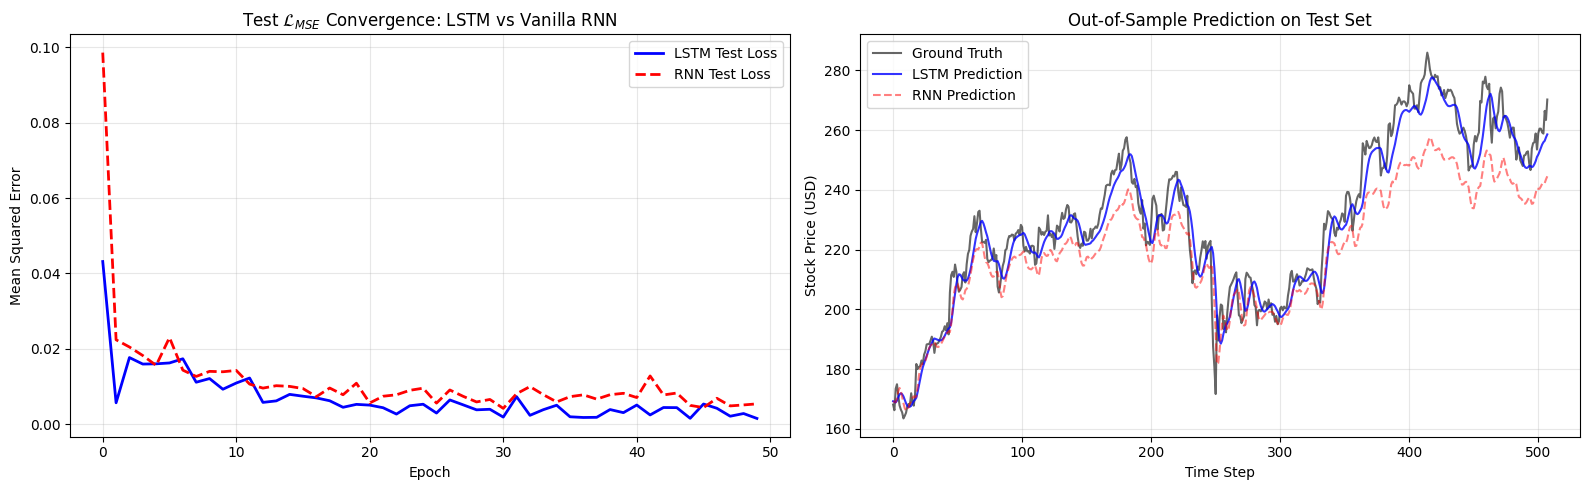

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 5-1. Loss Convergence Comparison
axes[0].plot(lstm_history['test_loss'], label='LSTM Test Loss', color='blue', linewidth=2)
axes[0].plot(rnn_history['test_loss'], label='RNN Test Loss', color='red', linestyle='--', linewidth=2)
axes[0].set_title(r"Test $\mathcal{L}_{MSE}$ Convergence: LSTM vs Vanilla RNN")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Mean Squared Error")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 5-2. Test Set Prediction Comparison (Inverse Transform)
# 성능 검증을 위해 Test 데이터셋에 대한 스케일 복원(Inverse Transform) 후 실제 스케일 예측
def get_predictions(model: nn.Module, loader: DataLoader) -> np.ndarray:
    model.eval()
    preds = []
    with torch.no_grad():
        for X_batch, _ in loader:
            X_batch = X_batch.to(device)
            preds.append(model(X_batch).cpu().numpy())
    return np.concatenate(preds, axis=0)

# 이전에 선언된 price_scaler 활용
lstm_preds_scaled = get_predictions(lstm_model, test_loader)
rnn_preds_scaled = get_predictions(rnn_model, test_loader)
actual_scaled = y_test_seq

lstm_preds_real = price_scaler.inverse_transform(lstm_preds_scaled)
rnn_preds_real = price_scaler.inverse_transform(rnn_preds_scaled)
actual_real = price_scaler.inverse_transform(actual_scaled)

axes[1].plot(actual_real, label='Ground Truth', color='black', alpha=0.6)
axes[1].plot(lstm_preds_real, label='LSTM Prediction', color='blue', alpha=0.8)
axes[1].plot(rnn_preds_real, label='RNN Prediction', color='red', alpha=0.5, linestyle='--')
axes[1].set_title("Out-of-Sample Prediction on Test Set")
axes[1].set_xlabel("Time Step")
axes[1].set_ylabel("Stock Price (USD)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## LSTM 최적화해보기

앞서 동일 하이퍼파라미터 조건에서 LSTM과 Vanilla RNN의 수렴 특성을 비교하였다. 본 섹션은 LSTM의 예측 품질을 좌우하는 두 축을 추가 분석한다.

1. **Look-back Window Size** ($W$) 민감도: 과거 정보를 얼마나 멀리까지 인코딩할지가 시계열 모델의 inductive bias를 결정한다.
2. **Custom LSTM Cell 구현**: `nn.LSTM`의 black-box 연산을 4-gate 수식 수준에서 재현하여 게이팅 메커니즘을 명시적으로 노출한다.

이후 기 구현된 시각화 파이프라인($\mathcal{L}_{MSE}$ convergence + Out-of-Sample prediction)을 그대로 재사용하여 RNN과의 성능 차이를 재확인한다.

### Window Size (Look-back) 민감도 분석

$W$는 입력 시퀀스 $X_t = [x_{t-W}, \dots, x_{t-1}]$의 길이를 결정하는 핵심 하이퍼파라미터이다.

- **$W$가 과소**: 장기 추세(Long-term trend) 포착 실패 $\rightarrow$ Underfitting.
- **$W$가 과대**: 무관한 과거 정보 유입 + $\mathcal{O}(W)$ BPTT 경로 증가로 기울기 희석(Gradient dilution) 및 학습 비용 상승.

동일 LSTM 아키텍처(`hidden=64`, `layers=2`)에서 $W \in \{20, 60, 120\}$에 대해 재학습한 뒤 Test MSE 수렴 곡선과 예측 궤적을 비교한다.

In [ ]:
# === Window Size 민감도 실험 ===
WINDOW_SIZES = [20, 60, 120, 240]
EPOCHS_WS = 30   # 민감도 분석 목적으로 Epoch 수 축소

ws_histories = {}
ws_predictions = {}

for ws in WINDOW_SIZES:
    # 1) 시퀀스 재구성 (Scaler도 새로 fitting)
    Xtr, ytr, Xte, yte, sc = preprocess_time_series(
        ts_data, train_ratio=0.8, look_back=ws
    )
    tr_ld = DataLoader(TimeSeriesDataset(Xtr, ytr),
                       batch_size=BATCH_SIZE, shuffle=True,
                       drop_last=True, pin_memory=True)
    te_ld = DataLoader(TimeSeriesDataset(Xte, yte),
                       batch_size=BATCH_SIZE, shuffle=False,
                       drop_last=False, pin_memory=True)

    # 2) LSTM 재초기화 (동일 구조)
    model_ws = LSTMRegressor(input_size=1, hidden_size=64,
                             num_layers=2, dropout=0.2).to(device)
    opt_ws = optim.Adam(model_ws.parameters(), lr=1e-3)

    print(f"\n[W = {ws}] X_train shape: {Xtr.shape}, X_test shape: {Xte.shape}")
    hist = train_and_evaluate(model_ws, opt_ws, tr_ld, te_ld, epochs=EPOCHS_WS)
    ws_histories[ws] = hist

    # 3) 예측 저장 (실제 스케일 복원)
    preds_scaled = get_predictions(model_ws, te_ld)
    ws_predictions[ws] = {
        'preds': sc.inverse_transform(preds_scaled),
        'actual': sc.inverse_transform(yte),
        'final_test_mse': hist['test_loss'][-1]
    }

print("\n=== Final Test MSE Summary ===")
for ws in WINDOW_SIZES:
    print(f"  W = {ws:3d} | Final Test MSE = {ws_predictions[ws]['final_test_mse']:.6f}")


[W = 20] X_train shape: (2251, 20, 1), X_test shape: (548, 20, 1)
Epoch [10/30] | Train loss: 0.0009 | Test loss: 0.0209
Epoch [20/30] | Train loss: 0.0006 | Test loss: 0.0103
Epoch [30/30] | Train loss: 0.0006 | Test loss: 0.0058

[W = 60] X_train shape: (2211, 60, 1), X_test shape: (508, 60, 1)
Epoch [10/30] | Train loss: 0.0007 | Test loss: 0.0120
Epoch [20/30] | Train loss: 0.0006 | Test loss: 0.0088
Epoch [30/30] | Train loss: 0.0005 | Test loss: 0.0066

[W = 120] X_train shape: (2151, 120, 1), X_test shape: (448, 120, 1)
Epoch [10/30] | Train loss: 0.0007 | Test loss: 0.0154
Epoch [20/30] | Train loss: 0.0006 | Test loss: 0.0110
Epoch [30/30] | Train loss: 0.0005 | Test loss: 0.0048

[W = 240] X_train shape: (2031, 240, 1), X_test shape: (328, 240, 1)
Epoch [10/30] | Train loss: 0.0008 | Test loss: 0.0196
Epoch [20/30] | Train loss: 0.0007 | Test loss: 0.0124
Epoch [30/30] | Train loss: 0.0006 | Test loss: 0.0100

=== Final Test MSE Summary ===
  W =  20 | Final Test MSE = 0.005

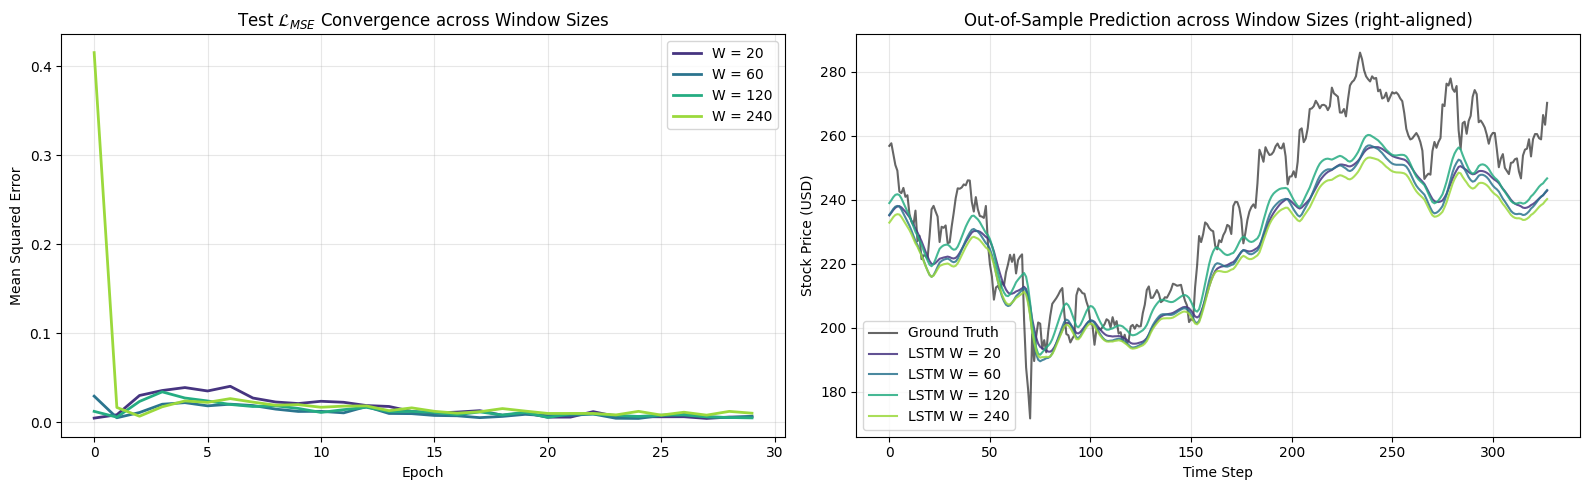

In [ ]:
# Window Size 시각화
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

cmap = plt.cm.viridis(np.linspace(0.15, 0.85, len(WINDOW_SIZES)))

# 1) Loss Convergence
for (ws, hist), color in zip(ws_histories.items(), cmap):
    axes[0].plot(hist['test_loss'], label=f'W = {ws}', color=color, linewidth=2)
axes[0].set_title(r"Test $\mathcal{L}_{MSE}$ Convergence across Window Sizes")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Mean Squared Error")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 2) Prediction (공통 길이로 우측 정렬)
min_len = min(len(p['preds']) for p in ws_predictions.values())
# Ground truth: 동일 test 구간이므로 어느 키를 참조해도 우측 min_len 구간은 일치
gt = ws_predictions[WINDOW_SIZES[0]]['actual'][-min_len:]
axes[1].plot(gt, label='Ground Truth', color='black', alpha=0.6)
for (ws, pred), color in zip(ws_predictions.items(), cmap):
    axes[1].plot(pred['preds'][-min_len:], label=f'LSTM W = {ws}',
                 color=color, alpha=0.85)
axes[1].set_title("Out-of-Sample Prediction across Window Sizes (right-aligned)")
axes[1].set_xlabel("Time Step")
axes[1].set_ylabel("Stock Price (USD)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Custom LSTM Cell 구현

`nn.LSTM`이 은닉한 4개 게이트 연산을 직접 구현하여 내부 동작을 노출한다. 표준 LSTM Cell은 다음 수식으로 정의된다.

$$
\begin{aligned}
f_t &= \sigma(W_f x_t + U_f h_{t-1} + b_f) & \text{(Forget Gate)}\\
i_t &= \sigma(W_i x_t + U_i h_{t-1} + b_i) & \text{(Input Gate)}\\
g_t &= \tanh(W_g x_t + U_g h_{t-1} + b_g) & \text{(Candidate)}\\
o_t &= \sigma(W_o x_t + U_o h_{t-1} + b_o) & \text{(Output Gate)}\\
C_t &= f_t \odot C_{t-1} + i_t \odot g_t & \text{(Cell State)}\\
h_t &= o_t \odot \tanh(C_t) & \text{(Hidden State)}
\end{aligned}
$$

연산 효율을 위해 4개 게이트의 선형 변환은 단일 `nn.Linear(*, 4H)` 호출로 병합한 후 `chunk(4, dim=-1)`로 분리한다 (PyTorch 공식 구현과 동일 관례).

Multi-layer stacking은 $l$-번째 레이어의 hidden state $h_t^{(l)}$을 $l{+}1$ 레이어의 입력으로 전달하여 구성하며, 중간 레이어에는 Dropout을 적용한다.

In [ ]:
import torch
import torch.nn as nn


class CustomLSTMRegressor(nn.Module):
    """
    Many-to-One 아키텍처 기반의 LSTM Regression 모델.
    nn.LSTM 내장 구현을 사용하며, hidden_size / num_layers / dropout을
    외부 하이퍼파라미터 블록에서 조정한다.
    """
    def __init__(self, input_size: int = 1, hidden_size: int = 64,
                 num_layers: int = 2, dropout: float = 0.2):
        super(CustomLSTMRegressor, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x (torch.Tensor): Input tensor of shape (B, W, C)
        Returns:
            torch.Tensor: Output tensor of shape (B, 1)
        """
        out, _ = self.lstm(x)                      # (B, W, H)
        last_hidden_state = out[:, -1, :]          # (B, H)
        predictions = self.fc(last_hidden_state)   # (B, 1)
        return predictions

### Custom LSTM 학습 실행

하단 셀 상단에 **조정 가능한 하이퍼파라미터**를 선언 블록으로 집약하였다. 값만 수정하여 구조/학습 설정을 즉시 변경할 수 있다.

- `CUSTOM_HIDDEN_SIZE`, `CUSTOM_NUM_LAYERS`: 모델 용량
- `CUSTOM_DROPOUT`: 정규화 강도 (num_layers > 1 일 때만 유효)
- `CUSTOM_LR`, `CUSTOM_EPOCHS`: 최적화 설정

기존 `train_loader`, `test_loader` (WINDOW_SIZE=60)를 재사용하여 앞서 학습된 `lstm_model`, `rnn_model`과 동일 조건에서 비교 가능하도록 한다.

In [ ]:
# ============================================================
# Custom LSTM 하이퍼파라미터 (이곳에서 조정)
# ============================================================
CUSTOM_INPUT_SIZE  = 1
CUSTOM_HIDDEN_SIZE = 32
CUSTOM_NUM_LAYERS  = 2
CUSTOM_DROPOUT     = 0.5
CUSTOM_LR          = 1e-4
CUSTOM_EPOCHS      = 50
# ============================================================

# 1) 모델 인스턴스화 (WINDOW_SIZE=60 loader 재사용)
custom_lstm_model = CustomLSTMRegressor(
    input_size=CUSTOM_INPUT_SIZE,
    hidden_size=CUSTOM_HIDDEN_SIZE,
    num_layers=CUSTOM_NUM_LAYERS,
    dropout=CUSTOM_DROPOUT
).to(device)

custom_optimizer = optim.Adam(custom_lstm_model.parameters(), lr=CUSTOM_LR)

# 2) 구조 및 파라미터 수 출력
n_params = sum(p.numel() for p in custom_lstm_model.parameters() if p.requires_grad)
print("[Custom LSTM Architecture]")
print(custom_lstm_model)
print(f"\nTrainable parameters: {n_params:,}")

# 3) 학습 (기존 train_and_evaluate 재사용)
print("\n--- Training Custom LSTM Model ---")
custom_lstm_history = train_and_evaluate(
    custom_lstm_model, custom_optimizer,
    train_loader, test_loader, epochs=CUSTOM_EPOCHS
)

[Custom LSTM Architecture]
CustomLSTMRegressor(
  (lstm): LSTM(1, 32, num_layers=2, batch_first=True, dropout=0.5)
  (fc): Linear(in_features=32, out_features=1, bias=True)
)

Trainable parameters: 12,961

--- Training Custom LSTM Model ---
Epoch [10/50] | Train loss: 0.0066 | Test loss: 0.0083
Epoch [20/50] | Train loss: 0.0024 | Test loss: 0.0246
Epoch [30/50] | Train loss: 0.0019 | Test loss: 0.0403
Epoch [40/50] | Train loss: 0.0017 | Test loss: 0.0366
Epoch [50/50] | Train loss: 0.0014 | Test loss: 0.0278


### LSTM Variants vs Vanilla RNN: 기 구현 시각화 재실행

앞서 정의한 `fig, axes = plt.subplots(1, 2, ...)` 기반 2-panel 레이아웃을 그대로 재사용한다.

- **Left**: Test $\mathcal{L}_{MSE}$ convergence (3-way: `nn.LSTM`, Custom LSTM, RNN).
- **Right**: Out-of-Sample prediction (inverse-scaled).

`lstm_history`, `rnn_history`, `lstm_preds_real`, `rnn_preds_real`, `actual_real`은 앞 셀에서 이미 계산되어 있으므로 Custom LSTM 결과만 추가 산출한다.

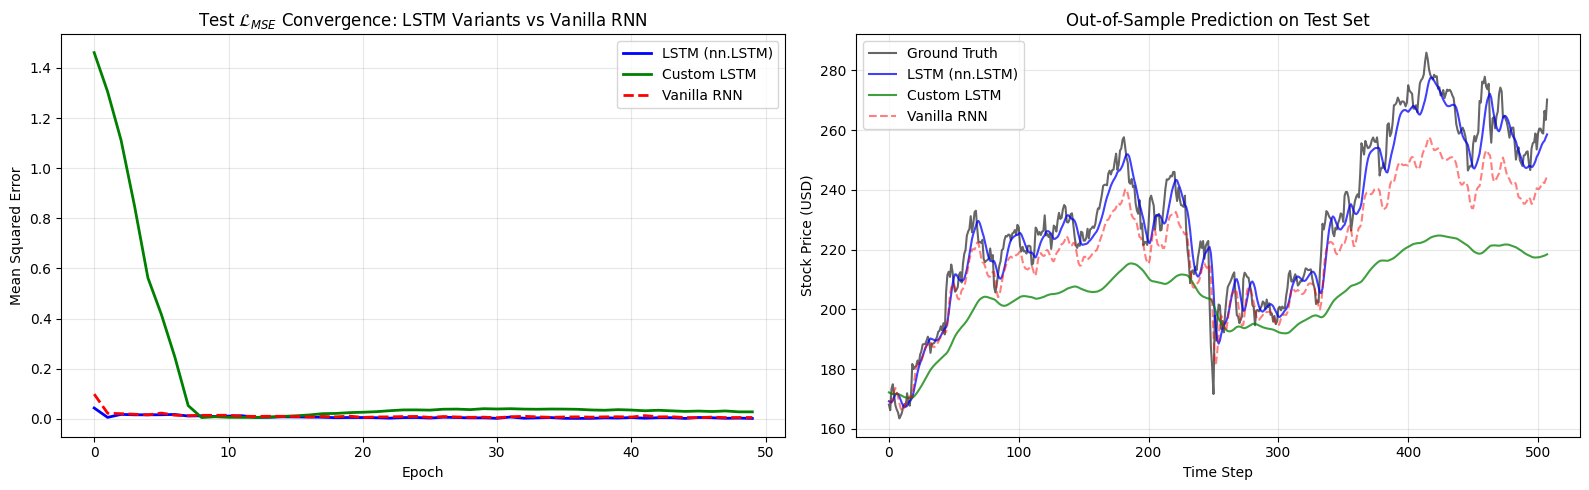


=== Final Test MSE Summary (Window=60, Epoch=last) ===
  LSTM (nn.LSTM) : 0.001515
  Custom LSTM    : 0.027786
  Vanilla RNN    : 0.005382


In [ ]:
# Custom LSTM 예측 (inverse scale)
custom_preds_scaled = get_predictions(custom_lstm_model, test_loader)
custom_preds_real   = price_scaler.inverse_transform(custom_preds_scaled)

# === 기 구현 시각화 재사용: 1x2 panel ===
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Panel 1: Loss Convergence Comparison (3-way)
axes[0].plot(lstm_history['test_loss'],        label='LSTM (nn.LSTM)',  color='blue',  linewidth=2)
axes[0].plot(custom_lstm_history['test_loss'], label='Custom LSTM',     color='green', linewidth=2)
axes[0].plot(rnn_history['test_loss'],         label='Vanilla RNN',     color='red',   linestyle='--', linewidth=2)
axes[0].set_title(r"Test $\mathcal{L}_{MSE}$ Convergence: LSTM Variants vs Vanilla RNN")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Mean Squared Error")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Panel 2: Out-of-Sample Prediction (3-way)
axes[1].plot(actual_real,       label='Ground Truth',          color='black', alpha=0.6)
axes[1].plot(lstm_preds_real,   label='LSTM (nn.LSTM)',        color='blue',  alpha=0.75)
axes[1].plot(custom_preds_real, label='Custom LSTM',           color='green', alpha=0.75)
axes[1].plot(rnn_preds_real,    label='Vanilla RNN',           color='red',   alpha=0.5, linestyle='--')
axes[1].set_title("Out-of-Sample Prediction on Test Set")
axes[1].set_xlabel("Time Step")
axes[1].set_ylabel("Stock Price (USD)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 최종 MSE 요약
print("\n=== Final Test MSE Summary (Window=60, Epoch=last) ===")
print(f"  LSTM (nn.LSTM) : {lstm_history['test_loss'][-1]:.6f}")
print(f"  Custom LSTM    : {custom_lstm_history['test_loss'][-1]:.6f}")
print(f"  Vanilla RNN    : {rnn_history['test_loss'][-1]:.6f}")

# Sentence Classification via LSTM

본 파트는 이산형(Discrete) 자연어 데이터를 처리하여 텍스트의 감성(긍정/부정)을 이진 분류(Binary Classification)하는 파이프라인을 구축한다.

Section 1에서 다룬 시계열 데이터가 연속적 차원 공간에서의 추세를 모델링했다면, 자연어 처리는 고정된 Vocabulary 내 이산적 토큰들의 시퀀스 $X = {w_1, w_2, \dots, w_T}$를 입력으로 받아 특정 클래스 $c \in {0, 1}$에 대한 사후 확률 $P(c|X)$를 추정하는 문제로 정의된다.

순환 신경망(RNN/LSTM)은 가변 길이(Variable-length) 시퀀스를 처리할 수 있으나, 미니 배치(Mini-batch) 연산을 위해서는 최대 시퀀스 길이에 맞춘 패딩(Padding)이 요구된다.

따라서 모델 아키텍처 설계 및 텐서 변환 이전에 탐색적 데이터 분석(EDA)을 통해 토큰 길이의 분포를 파악하고, 아웃라이어(Outlier)를 통제하여 연산 효율성과 메모리 최적화를 달성해야 한다. 이 과정은 후속 텍스트 전처리 및 $\mathcal{L}_{CE}$ 최적화의 기반이 된다.

![image](https://media.springernature.com/m685/springer-static/image/art%3A10.1038%2Fs41598-020-71450-8/MediaObjects/41598_2020_71450_Fig1_HTML.png)



## 자연어 데이터셋 로드 및 EDA

한국어 텍스트 감성 분석의 표준 벤치마크인 NSMC (Naver Sentiment Movie Corpus) 데이터셋을 활용한다.

본 데이터셋은 리뷰 텍스트와 함께 0(부정) 또는 1(긍정)의 Label을 포함한다.

결측치(Missing Values) 및 중복 데이터(Duplicates) 제거는 텍스트 분류 성능의 하한선(Lower Bound)을 결정하는 필수적인 전처리 과정이다.

또한, 각 리뷰의 텍스트 길이를 분석하여, 절단(Truncation) 및 패딩(Padding)의 기준이 되는 임계치(Threshold Length)를 경험적으로 도출한다.

In [ ]:
import urllib.request
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def load_and_clean_nsmc(url: str) -> pd.DataFrame:
    """
    지정된 URL에서 NSMC 데이터를 로드하고 결측치 및 중복을 제거한다.
    """
    file_name = url.split('/')[-1]
    urllib.request.urlretrieve(url, filename=file_name)

    df = pd.read_table(file_name)

    # 데이터 정제 (결측치 및 중복 제거)
    initial_len = len(df)
    df.drop_duplicates(subset=['document'], inplace=True)
    df.dropna(how='any', inplace=True)

    print(f"[{file_name}] Data Load & Clean: {initial_len} -> {len(df)} rows.")
    return df

### 데이터셋 다운로드 및 로드

In [ ]:
train_url = "https://raw.githubusercontent.com/e9t/nsmc/master/ratings_train.txt"
test_url = "https://raw.githubusercontent.com/e9t/nsmc/master/ratings_test.txt"

train_df = load_and_clean_nsmc(train_url)
test_df = load_and_clean_nsmc(test_url)

[ratings_train.txt] Data Load & Clean: 150000 -> 146182 rows.
[ratings_test.txt] Data Load & Clean: 50000 -> 49157 rows.


### 데이터셋 확인

In [ ]:
# 무작위로 확인할 샘플 개수 설정
n_samples = 5

# 1. 긍정 리뷰(label == 1) 샘플링
print("-" * 30)
print(f"[Positive Samples - {n_samples} examples]")
print("-" * 30)
positive_examples = train_df[train_df['label'] == 1].sample(n_samples, random_state=42)
for i, row in positive_examples.iterrows():
    print(f"Review: {row['document']}")
    print(f"Label: {row['label']} (Positive)")
    print("-" * 10)

# 2. 부정 리뷰(label == 0) 샘플링
print("\n" + "-" * 30)
print(f"[Negative Samples - {n_samples} examples]")
print("-" * 30)
negative_examples = train_df[train_df['label'] == 0].sample(n_samples, random_state=42)
for i, row in negative_examples.iterrows():
    print(f"Review: {row['document']}")
    print(f"Label: {row['label']} (Negative)")
    print("-" * 10)

------------------------------
[Positive Samples - 5 examples]
------------------------------
Review: 음악에 저절로 몸을 들썩이게 된다.
Label: 1 (Positive)
----------
Review: 유치하고 단순한 할리퀸이지만 그게 사랑스러워
Label: 1 (Positive)
----------
Review: 인류의 역사를 말하는 작품.
Label: 1 (Positive)
----------
Review: 잘보고있어요!! 이번주 화요일은 시험기간이라고 못봤어요.. 저 울음.. 엄마 혼자 봤어요..
Label: 1 (Positive)
----------
Review: 실화라는것에흥미를느껴봤다.역시동물나오는건슬퍼ㅠ뱀뱀죽엇을때너무슬펐다ㅠ0ㅠ
Label: 1 (Positive)
----------

------------------------------
[Negative Samples - 5 examples]
------------------------------
Review: 설정이 복잡하고 캐릭터가 죽어 있어 마지막 전에 질린다
Label: 0 (Negative)
----------
Review: 줄거리 진짜 꽝... 슈퍼가 보는맛에 버텼다...
Label: 0 (Negative)
----------
Review: 영화가 끝나갈무렵 범이가 칼맞고 쓰러졋을때 수경이가 발로 찾을때... 난 그장면이 제일 임팩트 잇는것같다!
Label: 0 (Negative)
----------
Review: 택시 시리즈의 수치.
Label: 0 (Negative)
----------
Review: 록키 6라... -_-;;
Label: 0 (Negative)
----------


### 클래스 불균형(Class Imbalance) 확인

In [ ]:
print("\n[Train Set Label Distribution]")
print(train_df['label'].value_counts(normalize=True))


[Train Set Label Distribution]
label
0    0.501717
1    0.498283
Name: proportion, dtype: float64


### 텍스트 시퀀스 길이 분석 (어절 단위 기반)

In [ ]:
# 형태소 분석 이전이므로, 공백 기준 분리(Whitespace Tokenization)를 임시 기준으로 사용함
train_df['length'] = train_df['document'].apply(lambda x: len(str(x).split()))

시각적인 확인을 위해 샘플 단어 설정

In [ ]:
sample_pos_text = "이 영화 정말 최고예요"
sample_neg_text = "진짜 시간 아깝네요 보지마세요"

### EDA 시각화

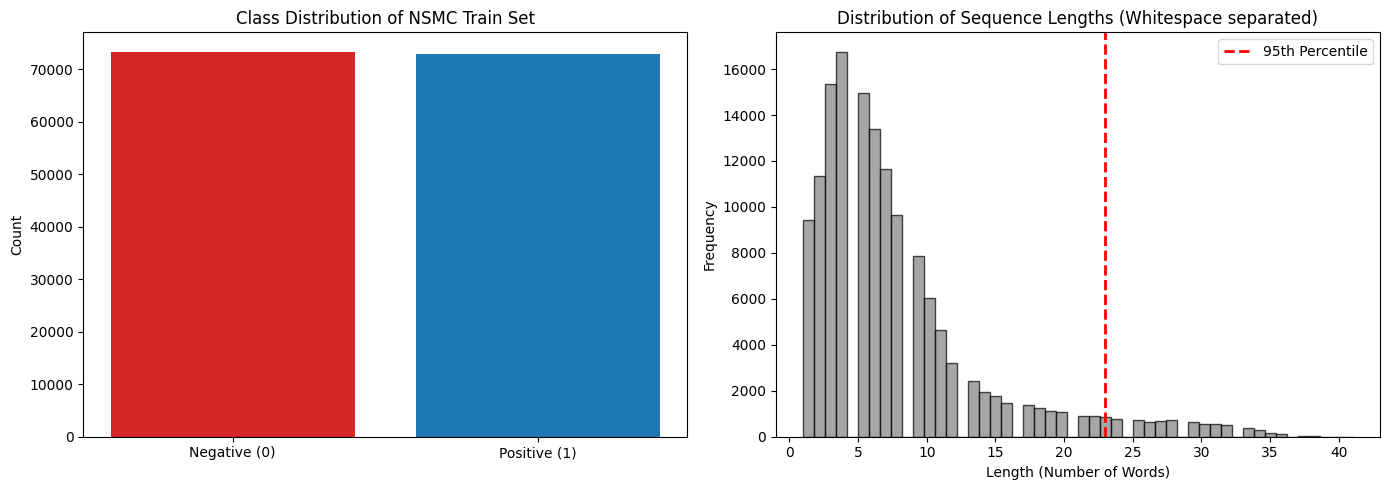

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Label Distribution
axes[0].bar(['Negative (0)', 'Positive (1)'], train_df['label'].value_counts().sort_index(), color=['#d62728', '#1f77b4'])
axes[0].set_title("Class Distribution of NSMC Train Set")
axes[0].set_ylabel("Count")

# Text Length Distribution
axes[1].hist(train_df['length'], bins=50, color='gray', edgecolor='black', alpha=0.7)
axes[1].set_title("Distribution of Sequence Lengths (Whitespace separated)")
axes[1].set_xlabel("Length (Number of Words)")
axes[1].set_ylabel("Frequency")
axes[1].axvline(np.percentile(train_df['length'], 95), color='red', linestyle='dashed', linewidth=2, label='95th Percentile') ## 95%에 레드 도트
axes[1].legend()

plt.tight_layout()
plt.show()

위 그림에서 약 95 길이만큼을 설정했다. (99%를 설정해도 무관함)

95% 데이터를 커버하는 길이를 확인 한 뒤 Padding 기준값으로 활용한다.

In [ ]:
optimal_max_len = int(np.percentile(train_df['length'], 95))
print(f"\nOptimal Max Sequence Length (covering 95% of data): {optimal_max_len}")


Optimal Max Sequence Length (covering 95% of data): 23


## 텍스트 전처리 (Vocab 생성, 정수 인코딩, Padding)

1. 자연어 텍스트는 이산적(Discrete) 심볼의 집합이다.

2. 신경망의 연산을 위해 텍스트 시퀀스 $X = {w_1, w_2, \dots, w_T}$를 연속형 벡터 공간으로 투영하기 위한 사전 단계로서, 각 토큰 $w_t$를 고유한 정수 인덱스 $i_t \in \mathbb{N}$로 매핑하는 정수 인코딩(Integer Encoding) 과정이 필수적이다. (tokenization 이라고도 함)

- chatgpt의 tokenization: https://platform.openai.com/tokenizer

3. 이 과정에서 훈련 데이터셋 기반의 어휘 집합(Vocabulary, $\mathcal{V}$)을 구축한다.


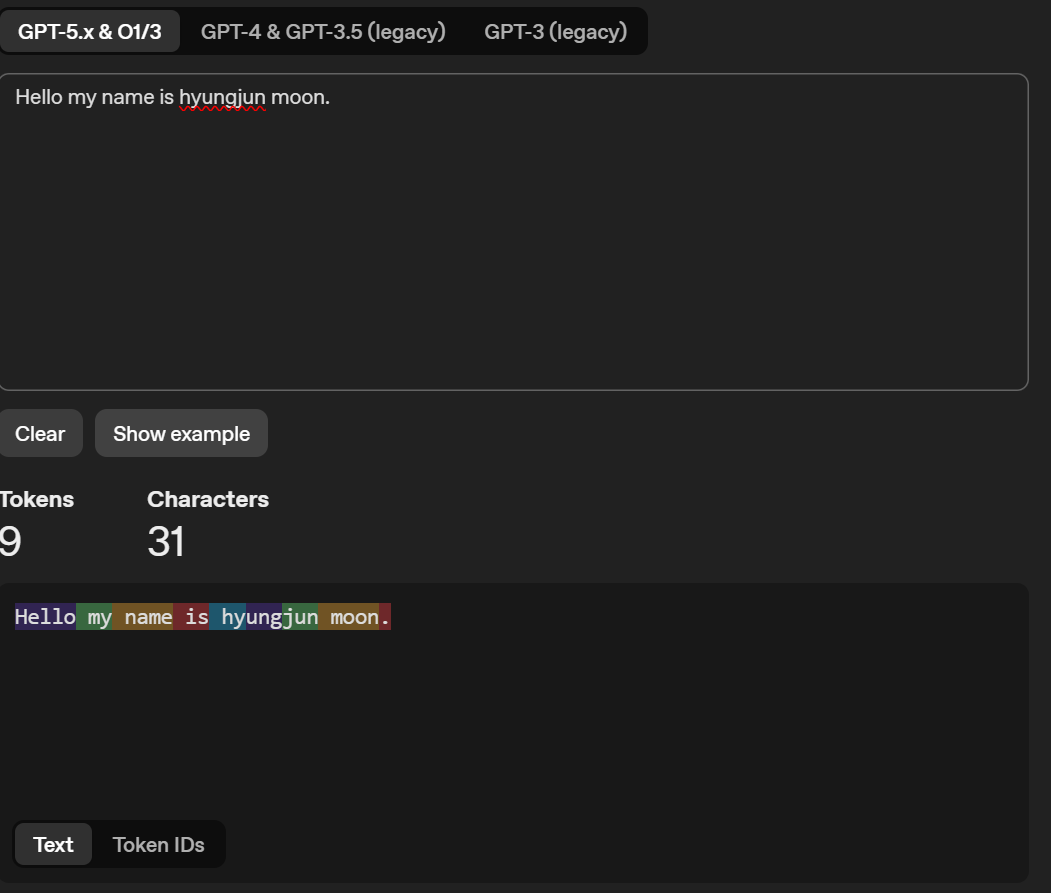

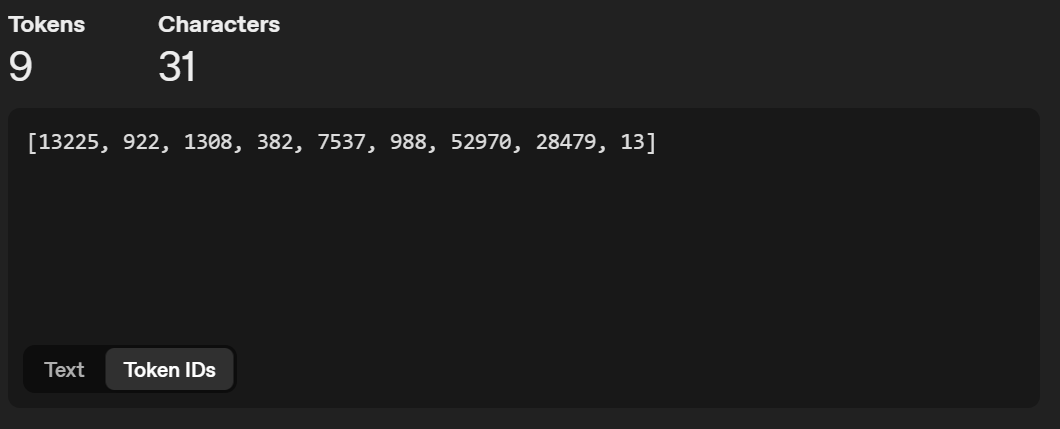

4. 희소 토큰(Rare tokens, 자주 보이지 않는 토큰)은 파라미터 공간을 불필요하게 확장하여 과적합(Overfitting)을 유발하므로, 출현 빈도가 임계치(min_freq) 미만인 토큰은 <UNK>(Unknown) 토큰으로 치환하여 OOV(Out-Of-Vocabulary) 문제에 대응한다.

5. 학습을 위해서는 시퀀스 길이를 정규화해야 한다. 앞선 EDA에서 도출한 임계 길이 $T_{max}$를 기준으로, 길이가 $T < T_{max}$인 시퀀스에는 <PAD> 토큰을 추가(Padding)하고, $T > T_{max}$인 시퀀스는 절단(Truncation)하여 차원을 통일한다.

In [ ]:
import numpy as np
import pandas as pd
from collections import Counter
from typing import List, Dict, Tuple

# 특수 토큰 정의 및 인덱스 할당
PAD_TOKEN, UNK_TOKEN = '<PAD>', '<UNK>'
PAD_IDX, UNK_IDX = 0, 1

### vocabulary를 만드는 함수 설정

In [ ]:
def build_vocabulary(corpus: pd.Series, min_freq: int = 2) -> Tuple[Dict[str, int], Dict[int, str]]:
    """
    훈련 말뭉치를 기반으로 Vocabulary를 구축한다.
    (주의: Data Leakage 방지를 위해 반드시 Train Set에 대해서만 수행해야 함)
    """
    counter = Counter()
    for text in corpus:
        # Part 2-1과 동일하게 공백 기반 토큰화 적용 (실제 연구에서는 Mecab, BPE 등 서브워드 토크나이저 권장)
        tokens = str(text).split()
        counter.update(tokens)

    # min_freq 이상 등장한 토큰만 필터링하여 Vocab 구성
    vocab_words = [PAD_TOKEN, UNK_TOKEN] + [word for word, freq in counter.items() if freq >= min_freq]

    word2idx = {word: idx for idx, word in enumerate(vocab_words)}
    idx2word = {idx: word for word, idx in word2idx.items()}

    return word2idx, idx2word

### 모든 text의 길이를 맞추기 위해 padding 함수 구성

In [ ]:
def encode_and_pad(
    corpus: pd.Series,
    word2idx: Dict[str, int],
    max_len: int
) -> np.ndarray:
    """
    텍스트를 정수 인덱스 시퀀스로 변환하고 max_len에 맞춰 Padding/Truncation을 수행한다.
    """
    encoded_corpus = []

    for text in corpus:
        tokens = str(text).split()
        # OOV 토큰은 UNK_IDX로 처리
        encoded = [word2idx.get(token, UNK_IDX) for token in tokens]

        # Truncation & Padding
        if len(encoded) >= max_len:
            encoded = encoded[:max_len]
        else:
            # Pre-padding 적용 (RNN 계열에서는 마지막 시점의 은닉 상태가 중요하므로 상황에 따라 Post-padding과 선택적 사용)
            encoded = [PAD_IDX] * (max_len - len(encoded)) + encoded

        encoded_corpus.append(encoded)

    return np.array(encoded_corpus, dtype=np.int64)

### Vocabulary 구축 (Train Set 기준)

In [ ]:
MIN_FREQ = 2 # 최소 두번 이상 등장해야 하도록 구성하기 ## 조정 가능한 파라미터
word2idx, idx2word = build_vocabulary(train_df['document'], min_freq=MIN_FREQ)
vocab_size = len(word2idx)
print(f"Vocabulary Size (min_freq={MIN_FREQ}): {vocab_size}")

Vocabulary Size (min_freq=2): 72856


전처리 과정 시각화 (Tokenization과 Word2idx)

In [ ]:
# 시각화 및 후속 단계 활용을 위한 샘플 선정
# (고정된 인덱스를 사용하거나 조건에 맞는 샘플을 명시적으로 추출)
sample_pos_text = "이 영화 정말 최고예요"
sample_neg_text = "진짜 시간 아깝네요 보지마세요"

def trace_transformation(texts: list, word2idx: dict):
    """
    텍스트가 토큰화 및 정수 인코딩되는 과정을 추적하여 리스트로 반환한다.
    """
    results = []
    for text in texts:
        # 1. Tokenization (공백 기준)
        tokens = str(text).split()

        # 2. Integer Encoding
        encoded = [word2idx.get(token, word2idx.get('<UNK>')) for token in tokens]

        results.append({
            "raw": text,
            "tokens": tokens,
            "encoded": encoded
        })
    return results

# 변환 수행
trace_samples = [sample_pos_text, sample_neg_text]
transformation_log = trace_transformation(trace_samples, word2idx)

# 시각화 출력 (컬럼 확장 구조)
print(f"{'Step / Sample':<20} | {'Positive Example':<30} | {'Negative Example':<30}")
print("-" * 85)
print(f"{'1. Raw Text':<20} | {transformation_log[0]['raw']:<30} | {transformation_log[1]['raw']:<30}")
print(f"{'2. Tokenized':<20} | {str(transformation_log[0]['tokens']):<30} | {str(transformation_log[1]['tokens']):<30}")
print(f"{'3. Word2Idx':<20} | {str(transformation_log[0]['encoded']):<30} | {str(transformation_log[1]['encoded']):<30}")

Step / Sample        | Positive Example               | Negative Example              
-------------------------------------------------------------------------------------
1. Raw Text          | 이 영화 정말 최고예요                   | 진짜 시간 아깝네요 보지마세요              
2. Tokenized         | ['이', '영화', '정말', '최고예요']      | ['진짜', '시간', '아깝네요', '보지마세요'] 
3. Word2Idx          | [155, 37, 84, 57129]           | [4, 2802, 828, 4065]          


### 정수 인코딩 및 패딩 적용

In [ ]:
# Part 2-1에서 도출한 optimal_max_len 사용 (예: 25로 가정)
MAX_LEN = optimal_max_len if 'optimal_max_len' in locals() else 25

In [ ]:
X_train_pad = encode_and_pad(train_df['document'], word2idx, MAX_LEN)
X_test_pad = encode_and_pad(test_df['document'], word2idx, MAX_LEN)

y_train = train_df['label'].values
y_test = test_df['label'].values

In [ ]:
# 3. 텐서 형상 검증
print(f"X_train_pad shape: {X_train_pad.shape}") # Expected: (N_train, MAX_LEN)
print(f"y_train shape: {y_train.shape}")         # Expected: (N_train,)
print(f"X_test_pad shape: {X_test_pad.shape}")   # Expected: (N_test, MAX_LEN)

# 샘플 데이터 인코딩 결과 확인
sample_idx = 150
print(f"\nOriginal text: {train_df['document'].iloc[sample_idx]}")
print(f"Encoded & Padded: {X_train_pad[sample_idx]}")

X_train_pad shape: (146182, 23)
y_train shape: (146182,)
X_test_pad shape: (49157, 23)

Original text: 그만좀 끌고 이제 끝내라. 지겹다 지겨워.
Encoded & Padded: [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0 698
 699 362 700 701   1]


전처리 과정 시각화

In [ ]:
import torch
def trace_full_transformation(texts: list, word2idx: dict, max_len: int):
    """
    텍스트가 정수 인코딩을 거쳐 패딩까지 완료되는 전 과정을 추적한다.
    """
    results = []
    for text in texts:
        # 1. Tokenization
        tokens = str(text).split()

        # 2. Integer Encoding
        encoded = [word2idx.get(token, UNK_IDX) for token in tokens]

        # 3. Padding (Pre-padding)
        if len(encoded) >= max_len:
            padded = encoded[:max_len]
        else:
            padded = [PAD_IDX] * (max_len - len(encoded)) + encoded

        results.append({
            "raw": text,
            "tokens": tokens,
            "encoded": encoded,
            "padded": padded
        })
    return results

# 샘플 데이터 변환 수행
sample_pos_text = "이 영화 정말 최고예요"
sample_neg_text = "진짜 시간 아깝네요 보지마세요"
trace_samples = [sample_pos_text, sample_neg_text]

full_log = trace_full_transformation(trace_samples, word2idx, MAX_LEN)

# 시각화 출력 (컬럼 확장 구조)
print(f"{'Step / Sample':<20} | {'Positive Example':<35} | {'Negative Example':<35}")
print("-" * 100)
print(f"{'1. Raw Text':<20} | {full_log[0]['raw']:<35} | {full_log[1]['raw']:<35}")
print(f"{'2. Tokenized':<20} | {str(full_log[0]['tokens']):<35} | {str(full_log[1]['tokens']):<35}")
print(f"{'3. Word2Idx':<20} | {str(full_log[0]['encoded']):<35} | {str(full_log[1]['encoded']):<35}")
print(f"{'4. Padding (Input)':<20} | {str(full_log[0]['padded']):<35} | {str(full_log[1]['padded']):<35}")

# 최종 Tensor 형태 확인 (Batch 차원 포함)
input_tensor = torch.tensor([full_log[0]['padded'], full_log[1]['padded']], dtype=torch.long)
print(f"\nFinal Input Tensor Shape: {input_tensor.shape}") # Expected: (2, MAX_LEN)

Step / Sample        | Positive Example                    | Negative Example                   
----------------------------------------------------------------------------------------------------
1. Raw Text          | 이 영화 정말 최고예요                        | 진짜 시간 아깝네요 보지마세요                   
2. Tokenized         | ['이', '영화', '정말', '최고예요']           | ['진짜', '시간', '아깝네요', '보지마세요']      
3. Word2Idx          | [155, 37, 84, 57129]                | [4, 2802, 828, 4065]               
4. Padding (Input)   | [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 155, 37, 84, 57129] | [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 4, 2802, 828, 4065]

Final Input Tensor Shape: torch.Size([2, 23])


## PyTorch Text DataLoader 구축

전처리 파이프라인을 통해 $T_{max}$ 길이로 정규화된 이산형 정수 시퀀스(Discrete Integer Sequence) 행렬을 PyTorch의 미니 배치(Mini-batch) 연산에 최적화된 형태로 변환한다.

In [ ]:
import torch
from torch.utils.data import TensorDataset, DataLoader

# 1. Numpy 배열을 PyTorch Tensor로 변환 및 데이터 타입 강제
# nn.Embedding 연산을 위해 입력 X는 반드시 long 타입(int64)이어야 함
X_train_tensor = torch.tensor(X_train_pad, dtype=torch.long)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)

X_test_tensor = torch.tensor(X_test_pad, dtype=torch.long)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

# 2. TensorDataset 구축
# 메모리에 모든 텐서가 적재된 상태이므로 커스텀 Dataset 클래스 대신 TensorDataset을 활용하여 오버헤드 최소화
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

In [ ]:
# 3. DataLoader 인스턴스화
# 텍스트 시퀀스 처리 시 임베딩 계층 및 LSTM의 메모리 점유율이 높으므로, GPU VRAM 제약에 따라 BATCH_SIZE 조절 필요
BATCH_SIZE = 128

train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,          # 에포크마다 미니 배치 $\mathcal{B}$ 구성 무작위화
    drop_last=True,        # 학습 안정성을 위해 불완전한 크기의 마지막 배치 버림
    pin_memory=True        # Host to Device 전송 병목 완화
)

test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    drop_last=False,
    pin_memory=True
)

In [ ]:
# 4. DataLoader 메모리 매핑 및 텐서 형상 검증
sample_X, sample_y = next(iter(train_loader))
print(f"Batch Text Sequence (X) shape: {sample_X.shape}") # Expected: (128, MAX_LEN)
print(f"Batch Text Sequence (X) dtype: {sample_X.dtype}") # Expected: torch.int64
print(f"Batch Label (y) shape: {sample_y.shape}")         # Expected: (128,)
print(f"Batch Label (y) dtype: {sample_y.dtype}")         # Expected: torch.int64

Batch Text Sequence (X) shape: torch.Size([128, 23])
Batch Text Sequence (X) dtype: torch.int64
Batch Label (y) shape: torch.Size([128])
Batch Label (y) dtype: torch.int64


## Word Embedding이 결합된 LSTM Classification 모델 설계

### 워드 임베딩(Word Embedding)

컴퓨터는 자연어 텍스트를 있는 그대로 연산할 수 없다.

따라서 단어를 수학적 벡터(Vector)로 변환하는 과정이 필요하며, 이는 역사적으로 3단계를 거쳐 발전해 왔다.

#### 1단계: 정수 인코딩 (Integer Encoding) - 단어에 고유 번호표 부여

가장 직관적인 방법은 사전(Vocabulary)을 구축하고 각 단어에 고유한 정수 번호를 부여하는 것이다.



- 사과 = 1

- 바나나 = 2

- 고양이 = 3

**문제점**: 컴퓨터는 숫자의 '크기'를 관계로 오해한다. '사과(1) + 1 = 바나나(2)'라는 잘못된 수학적 연관성을 딥러닝 모델이 학습할 위험이 존재한다.

#### 2단계: 원-핫 인코딩 (One-Hot Encoding) - 단어를 독립된 차원으로 분리

숫자의 크기가 가지는 오해를 풀기 위해, 전체 단어 사전의 크기(예: 10,000개)만큼의 0으로 채워진 텐서를 생성하고, 해당 단어의 인덱스 위치만 1로 표시(Hot)한다.

- 사과 = [1, 0, 0, 0, ..., 0]

- 바나나 = [0, 1, 0, 0, ..., 0]

- 고양이 = [0, 0, 1, 0, ..., 0]

한계점

1. 차원의 저주 (Curse of Dimensionality): 단어가 10만 개라면 벡터의 차원도 10만이 되며, 99.9%가 0으로 채워져 메모리 낭비가 극심해진다.
2. 단어 간의 단절 (Orthogonality): 사과와 바나나는 과일이라는 의미적 공통점이 존재하지만, 두 원-핫 벡터를 내적(Dot Product)하면 항상 0이 된다. 즉, 컴퓨터에게 모든 단어는 서로 완전히 무관한(직교하는) 독립적 존재로 인식된다.

#### 3단계: 워드 임베딩 (Word Embedding) - 의미를 담은 밀집 벡터(Dense Vector) 공간

원-핫 인코딩의 희소성(Sparsity) 문제를 해결하기 위해, 단어들을 훨씬 저차원(예: 128차원)의 '벡터 공간(Vector Space)' 위로 사영(Projection)하여 배치한다. 이를 워드 임베딩이라 한다.

In [ ]:
# 1. 자연어 시퀀스
text = ["사과", "바나나", "고양이"]

# 단계 1: Integer Encoding (단순 번호표)
# 숫자의 크기가 모델에 잘못된 선형적 관계를 학습시킬 수 있음.
integer_encoded = [1, 2, 3]

# 단계 2: One-Hot Encoding (희소 벡터 - Sparse Vector)
# 단어 사전 크기가 10,000이라고 가정할 때, $\mathbb{R}^{10000}$ 차원의 벡터가 생성됨.
# 단어 간 내적(Dot Product)이 항상 0이 되어 문맥적 유사도를 파악할 수 없음.
one_hot_apple  = [1, 0, 0, 0, 0, 0] # (생략)
one_hot_banana = [0, 1, 0, 0, 0, 0] # (생략)
one_hot_cat    = [0, 0, 1, 0, 0, 0] # (생략)

# 단계 3: Word Embedding (밀집 벡터 - Dense Vector)
# 모델이 $\mathcal{L}_{CE}$를 최소화하는 역전파(Backpropagation) 과정을 통해
# 각 단어의 잠재적 특성(Latent Feature) 값을 스스로 학습함.
# 예: [단맛의 정도, 크기, 동물성] 차원이라고 가정한 직관적 예시
embedded_apple  = [ 0.9,  0.2, -0.8]
embedded_banana = [ 0.8,  0.3, -0.9]
embedded_cat    = [-0.1,  0.4,  0.9]

# 결론:
# 임베딩 공간에서는 사과(0.9, 0.2, -0.8)와 바나나(0.8, 0.3, -0.9)의
# 벡터 유클리디안 거리(Euclidean Distance)가 가깝게 분포하므로,
# 딥러닝 모델이 문맥적, 의미론적 유사성을 수학적으로 연산할 수 있게 된다.

Embedding 시각화

In [ ]:
import torch
import torch.nn as nn
import pandas as pd

sample_pos_text = "이 영화 정말 최고예요"
sample_neg_text = "진짜 시간 아깝네요 보지마세요"
samples = [sample_pos_text, sample_neg_text]

# 2. 임베딩 레이어 초기화 (가중치 고정)
# vocab_size는 이전 섹션에서 구축된 값을 참조함
dummy_embedding = nn.Embedding(num_embeddings=vocab_size, embedding_dim=128, padding_idx=PAD_IDX)

def trace_entire_pipeline(texts, word2idx, embedding_layer, max_len):
    pipeline_results = []
    embedding_layer.eval()

    for text in texts:
        # Step 1: Tokenization
        tokens = str(text).split()

        # Step 2: Word2Idx (Integer Encoding)
        encoded = [word2idx.get(token, UNK_IDX) for token in tokens]

        # Step 3: Padding (Pre-padding)
        if len(encoded) >= max_len:
            padded = encoded[:max_len]
        else:
            padded = [PAD_IDX] * (max_len - len(encoded)) + encoded

        # Step 4: Embedding Projection
        input_tensor = torch.tensor(padded, dtype=torch.long).unsqueeze(0)
        with torch.no_grad():
            embedded = embedding_layer(input_tensor) # (1, max_len, embed_dim)

        # 시각화를 위해 리스트 형태로 저장
        pipeline_results.append({
            "raw": text,
            "tokens": tokens,
            "encoded": encoded,
            "padded": padded,
            "embedded": embedded[0].numpy().tolist() # (max_len, embed_dim)
        })
    return pipeline_results

# 파이프라인 실행
results = trace_entire_pipeline(samples, word2idx, dummy_embedding, MAX_LEN)

# 3. 통합 시각화 출력
print(f"{'Pipeline Stage':<20} | {'Positive Sample (1)':<45} | {'Negative Sample (0)':<45}")
print("-" * 115)

# Raw, Tokens, Encoded, Padded 출력
stages = [("1. Raw Text", "raw"), ("2. Tokenized", "tokens"), ("3. Word2Idx", "encoded"), ("4. Padding", "padded")]
for label, key in stages:
    print(f"{label:<20} | {str(results[0][key]):<45} | {str(results[1][key]):<45}")

print("-" * 115)
print(f"{'5. Embedding Projection (Vector Space)':^115}")
print("-" * 115)

# Embedding Vector 출력 (각 타임스텝별로 출력)
for t in range(MAX_LEN):
    pos_vec = [round(v, 3) for v in results[0]['embedded'][t]]
    neg_vec = [round(v, 3) for v in results[1]['embedded'][t]]
    token_p = results[0]['padded'][t]
    token_n = results[1]['padded'][t]

    # 0(PAD)인 경우 시각적 구분을 위해 표시
    p_label = f"IDX:{token_p}" if token_p != 0 else "PAD"
    n_label = f"IDX:{token_n}" if token_n != 0 else "PAD"

    print(f"Time {t} ({p_label:>7}) | {str(pos_vec):<45} | ({n_label:>7}) {str(neg_vec):<45}")

Pipeline Stage       | Positive Sample (1)                           | Negative Sample (0)                          
-------------------------------------------------------------------------------------------------------------------
1. Raw Text          | 이 영화 정말 최고예요                                  | 진짜 시간 아깝네요 보지마세요                             
2. Tokenized         | ['이', '영화', '정말', '최고예요']                     | ['진짜', '시간', '아깝네요', '보지마세요']                
3. Word2Idx          | [155, 37, 84, 57129]                          | [4, 2802, 828, 4065]                         
4. Padding           | [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 155, 37, 84, 57129] | [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 4, 2802, 828, 4065]
-------------------------------------------------------------------------------------------------------------------
                                      5. Embedding Projection (Vector Space)                                       
---

## 모델 설계

Padding Index Ignorance: 연산 효율성을 위해 추가된 <PAD> 토큰은 의미적 가치가 없으므로, nn.Embedding 선언 시 padding_idx를 명시하여 해당 인덱스의 기울기(Gradient) 업데이트를 차단해야 한다.

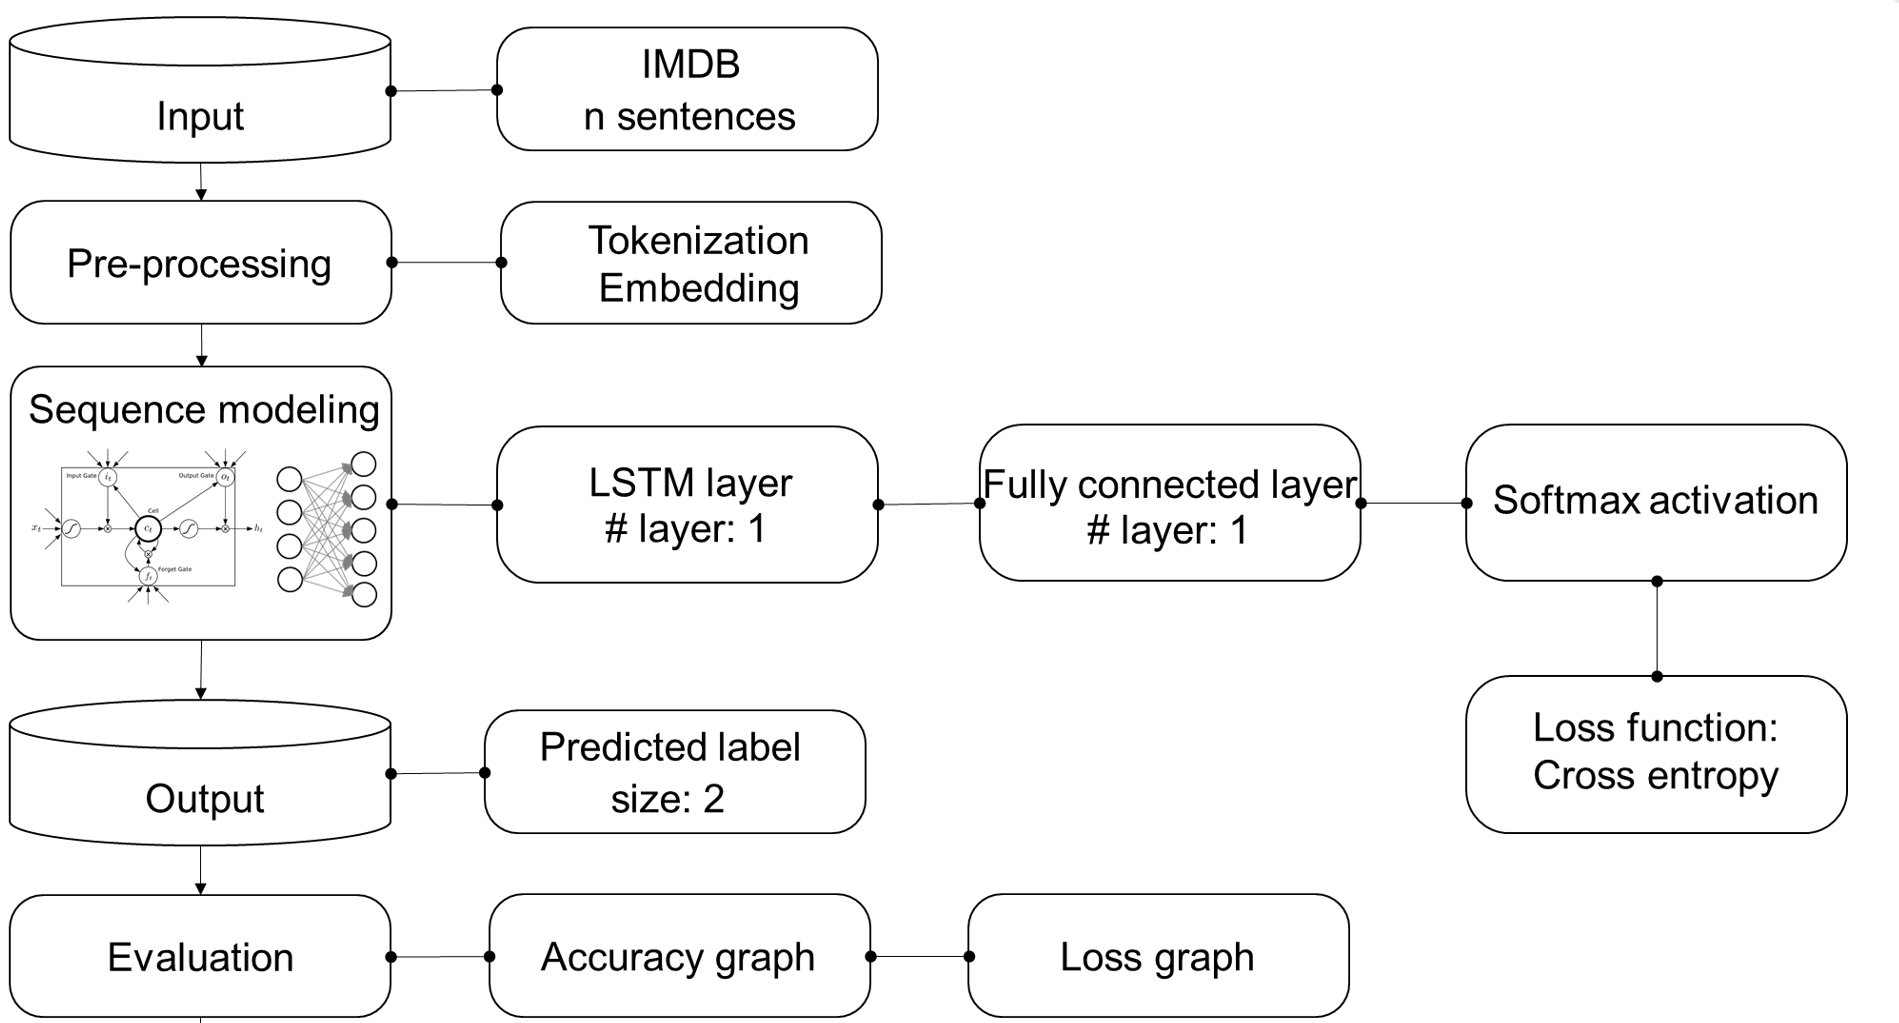

In [ ]:
import torch
import torch.nn as nn

class LSTMClassifier(nn.Module):
    """
    텍스트 분류를 위한 Word Embedding 및 LSTM 결합 아키텍처.
    N-way Classification으로의 확장을 고려하여 출력 차원을 num_classes로 일반화함.
    """
    def __init__(
        self,
        vocab_size: int,
        embed_dim: int = 128,
        hidden_dim: int = 256,
        num_classes: int = 2,
        num_layers: int = 2,
        dropout: float = 0.3,
        pad_idx: int = 0
    ):
        super(LSTMClassifier, self).__init__()

        # 1. Word Embedding Layer
        # pad_idx에 해당하는 임베딩 벡터는 0으로 초기화되며, 학습 과정에서 업데이트되지 않음
        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embed_dim,
            padding_idx=pad_idx
        )

        # 2. LSTM Layer
        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )

        # 3. Classifier (Fully Connected Layer)
        # Regularization을 위한 Dropout 추가
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x (torch.Tensor): Integer encoded sequence of shape (B, T_max)
        Returns:
            torch.Tensor: Class logits of shape (B, C)
        """
        # (B, T_max) -> (B, T_max, D_emb)
        embedded = self.embedding(x)

        # out: (B, T_max, H_dim)
        # hidden: (num_layers, B, H_dim)
        # cell: (num_layers, B, H_dim)
        out, (hidden, cell) = self.lstm(embedded)

        # Many-to-One: 마지막 레이어의 최종 Hidden State 추출
        # 형태: (B, H_dim)
        last_hidden = hidden[-1, :, :]

        # Dropout 적용 후 선형 사영을 통해 Logit 도출
        # (B, H_dim) -> (B, C)
        logits = self.fc(self.dropout(last_hidden))

        return logits

## 학습 루프 구현 및 모델 학습

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np

# 1. 하드웨어 디바이스 할당 및 모델 초기화
device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')

# Part 2-2, 2-4에서 정의된 변수 재사용 가정 (vocab_size, PAD_IDX 등)
model = LSTMClassifier(
    vocab_size=vocab_size,
    embed_dim=128,
    hidden_dim=256,
    num_classes=2,
    num_layers=2,
    dropout=0.3,
    pad_idx=PAD_IDX
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5) # L2 Regularization 추가

# 2. 모델 학습 및 평가 파이프라인
def train_and_eval_classifier(
    model: nn.Module,
    train_loader: torch.utils.data.DataLoader,
    test_loader: torch.utils.data.DataLoader,
    epochs: int = 10
):
    for epoch in range(epochs):
        # Training Phase
        model.train()
        train_loss, correct_train, total_train = 0.0, 0, 0

        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            optimizer.zero_grad()
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            loss.backward()

            # Gradient Clipping
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            optimizer.step()

            train_loss += loss.item() * X_batch.size(0)
            preds = torch.argmax(logits, dim=1)
            correct_train += (preds == y_batch).sum().item()
            total_train += y_batch.size(0)

        train_acc = correct_train / total_train

        # Validation Phase
        model.eval()
        test_loss, correct_test, total_test = 0.0, 0, 0
        with torch.no_grad():
            for X_batch, y_batch in test_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                logits = model(X_batch)
                loss = criterion(logits, y_batch)

                test_loss += loss.item() * X_batch.size(0)
                preds = torch.argmax(logits, dim=1)
                correct_test += (preds == y_batch).sum().item()
                total_test += y_batch.size(0)

        test_acc = correct_test / total_test

        print(f"Epoch [{epoch+1}/{epochs}] "
              f"Train : {train_loss/total_train:.4f}, Acc: {train_acc:.4f} | "
              f"Test : {test_loss/total_test:.4f}, Acc: {test_acc:.4f}")

# 3. 모델 학습 수행
EPOCHS = 5
print("--- Training Sentence Classification Model ---")
train_and_eval_classifier(model, train_loader, test_loader, epochs=EPOCHS)

--- Training Sentence Classification Model ---
Epoch [1/5] Train : 0.5615, Acc: 0.6868 | Test : 0.4863, Acc: 0.7502
Epoch [2/5] Train : 0.4289, Acc: 0.7870 | Test : 0.4374, Acc: 0.7815
Epoch [3/5] Train : 0.3521, Acc: 0.8338 | Test : 0.4336, Acc: 0.7861
Epoch [4/5] Train : 0.2969, Acc: 0.8624 | Test : 0.4531, Acc: 0.7844
Epoch [5/5] Train : 0.2571, Acc: 0.8812 | Test : 0.4785, Acc: 0.7799


학습이 완료된 이후에는, 훈련 데이터 분포 밖의(Out-of-Distribution) 임의의 자연어 문장에 대해 전처리 파이프라인(Tokenization $\rightarrow$ Integer Encoding $\rightarrow$ Padding)을 동일하게 적용하여 모델의 추론(Inference) 결과를 검증한다.

In [ ]:
# 4. 임의의 문장에 대한 추론(Inference) 함수 구현
def predict_sentiment(sentence: str, model: nn.Module, word2idx: dict, max_len: int) -> float:
    """
    단일 문장을 입력받아 전처리를 수행하고 긍정(1) 클래스에 대한 사후 확률을 반환한다.
    """
    model.eval()

    # Text Preprocessing (동일한 Tokenization 적용)
    tokens = sentence.split()
    encoded = [word2idx.get(token, word2idx.get('<UNK>')) for token in tokens]

    # Padding
    if len(encoded) >= max_len:
        padded = encoded[:max_len]
    else:
        padded = [word2idx.get('<PAD>')] * (max_len - len(encoded)) + encoded

    # Tensor Transformation
    tensor_input = torch.tensor(padded, dtype=torch.long).unsqueeze(0).to(device) # (1, T_max)

    with torch.no_grad():
        logits = model(tensor_input)
        # Logit을 확률로 변환하기 위해 Softmax 적용
        probs = torch.softmax(logits, dim=1)
        positive_prob = probs[0][1].item() # 긍정(인덱스 1) 확률 추출

    return positive_prob

## $\mathcal{L}_{CE}$ 기반 예측 테스트

In [ ]:
# 5. 추론 테스트
sample_sentences = [
    "재밌네요",
    "별로입니다",
    "기대 안 하고 봤는데 생각보다 흥미진진함"
]

print("\n--- Inference Test ---")
for text in sample_sentences:
    pos_prob = predict_sentiment(text, model, word2idx, MAX_LEN)
    prediction = "Positive" if pos_prob > 0.5 else "Negative"
    print(f"Input: {text}")
    print(f"Prediction: {prediction} (Positive Probability: {pos_prob:.4f})\n")


--- Inference Test ---
Input: 재밌네요
Prediction: Positive (Positive Probability: 0.9678)

Input: 별로입니다
Prediction: Negative (Positive Probability: 0.0147)

Input: 기대 안 하고 봤는데 생각보다 흥미진진함
Prediction: Positive (Positive Probability: 0.9904)



# Part 3: Time-Series Regression via CNN-LSTM Hybrid Architecture

본 파트는 Part 1의 LSTM 기반 회귀 파이프라인을 확장하여, 1D Convolutional Neural Network(CNN)와 LSTM을 계층적으로 결합한 Hybrid 아키텍처를 구축한다.

단변량(Univariate) 시계열에서는 LSTM 단독 구조만으로도 시간적 의존성(Temporal Dependency) 모델링이 충분하나, 실제 금융 시장에서는 시가(Open), 고가(High), 저가(Low), 종가(Close), 거래량(Volume)으로 구성된 **다변량(Multivariate) 시계열**이 주어진다.

이러한 고차원 입력 공간에서는 (1) 각 시점 내 **채널 간 지역적 상호작용(Local Cross-Channel Interaction)** 과 (2) 시점 간 **장기 의존성**이 동시에 존재하며, 단일 아키텍처로는 두 신호를 효율적으로 포착하기 어렵다.

CNN-LSTM Hybrid는 다음 Inductive Bias를 조합하여 이를 해결한다.

- **1D CNN (Local Feature Extractor)**: 커널 크기 $K$의 1차원 합성곱을 적용하여, 인접 $K$개 타임스텝 구간 내의 지역적 패턴(예: 단기 모멘텀, 스파이크)을 추출한다.
- **LSTM (Temporal Aggregator)**: CNN이 산출한 고수준 특성 시퀀스를 입력으로 받아 장기 의존성을 모델링한다.

결과적으로 입력 시퀀스의 **공간적(채널 간) 특성 압축**과 **시간적 의존성 모델링**이 분리된 서브 네트워크에서 수행되므로, 파라미터 효율성과 일반화 성능이 향상된다.

수학적 구조는 다음과 같다. 입력 $X \in \mathbb{R}^{B \times W \times C_{in}}$에 대해,

$$
Z = \text{MaxPool}\left( \sigma\left( \text{Conv1D}_{K, C_{out}}(X^{\top}) \right) \right) \in \mathbb{R}^{B \times C_{out} \times W'}
$$

여기서 $W' = \lfloor (W - K + 2P)/S + 1 \rfloor$ 이후 풀링에 의해 추가 축소된다. 이후 차원을 재정렬하여 LSTM에 주입한다.

$$
h_{W'} = \text{LSTM}(Z^{\top}), \quad \hat{y} = W_{fc}\, h_{W'} + b_{fc}
$$

## 다변량 시계열 데이터셋 수집 및 EDA

Part 1에서 활용한 yfinance API를 통해 동일 종목(AAPL)의 **OHLCV 5개 채널**을 수집한다.

- **OHLC (Open, High, Low, Close)**: 가격 변동의 일중 동학(Intraday Dynamics)을 압축 표현하는 네 가지 핵심 통계량.
- **Volume**: 시장 참여자의 활성도를 나타내는 유동성 지표. 가격과 상이한 스케일 및 분포 특성을 가짐.

Target Variable은 $t+1$ 시점의 **Close Price**로 설정하여 Part 1과의 공정한 비교(Apples-to-apples Comparison)를 보장한다.

In [ ]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def fetch_multivariate_financial_data(ticker: str, start_date: str, end_date: str) -> pd.DataFrame:
    """
    OHLCV 5채널 다변량 시계열을 수집한다.
    CNN의 채널 간 합성곱 연산을 위한 입력 특성 공간을 구성.
    """
    df = yf.download(ticker, start=start_date, end=end_date)

    if df.empty:
        raise ValueError(f"No data fetched for {ticker}. Check ticker or date range.")
    assert df.isnull().sum().sum() == 0, "Missing values detected in the dataset."

    # MultiIndex 컬럼 처리 (yfinance 신규 버전 호환)
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)

    # OHLCV 5채널 추출 (순서 고정)
    mv_data = df[['Open', 'High', 'Low', 'Close', 'Volume']].copy()

    return mv_data

### 데이터 수집 (종목, 시작일자, 종료일자)

In [ ]:
# 1. 다변량 데이터 수집
ticker_symbol = 'AAPL'
start_idx = '2015-01-01'
end_idx = '2026-04-11'

mv_ts_data = fetch_multivariate_financial_data(ticker_symbol, start_idx, end_idx)
print(f"Data shape: {mv_ts_data.shape}")  # (N_days, 5)
print(mv_ts_data.head())

/tmp/ipykernel_3265/847169956.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed

Data shape: (2834, 5)
Price            Open       High        Low      Close     Volume
Date                                                             
2015-01-02  24.671149  24.682224  23.776352  24.214891  212818400
2015-01-05  23.984547  24.064282  23.346673  23.532719  257142000
2015-01-06  23.596954  23.794075  23.173918  23.534939  263188400
2015-01-07  23.743133  23.964618  23.632391  23.864950  160423600
2015-01-08  24.192741  24.839475  24.075353  24.781889  237458000


### 기초 통계량 및 채널 간 스케일 불균형 확인

In [ ]:
# 2. 채널별 기초 통계량
print(f"[{ticker_symbol}] Multivariate Time-Series Description:")
print(mv_ts_data.describe())

# 스케일 불균형 수치화: OHLC는 ~10^2, Volume은 ~10^7 수준
print("\n[Channel-wise Scale Disparity (Max/Min Ratio)]")
print(mv_ts_data.max() / mv_ts_data.min())

[AAPL] Multivariate Time-Series Description:
Price         Open         High          Low        Close        Volume
count  2834.000000  2834.000000  2834.000000  2834.000000  2.834000e+03
mean    109.823976   111.009807   108.717360   109.912520  1.098528e+08
std      76.985574    77.795768    76.230185    77.044041  6.798341e+07
min      20.507342    20.887866    20.386579    20.584816  1.791060e+07
25%      37.090351    37.434596    36.715981    37.106536  6.293322e+07
50%     107.551446   109.184952   105.745663   107.549049  9.302575e+07
75%     170.732576   172.182001   169.129026   171.110992  1.356629e+08
max     285.932471   288.350192   283.035157   285.922455  6.488252e+08

[Channel-wise Scale Disparity (Max/Min Ratio)]
Price
Open      13.942932
High      13.804674
Low       13.883406
Close     13.889969
Volume    36.225766
dtype: float64


### 다변량 시각화 (EDA)

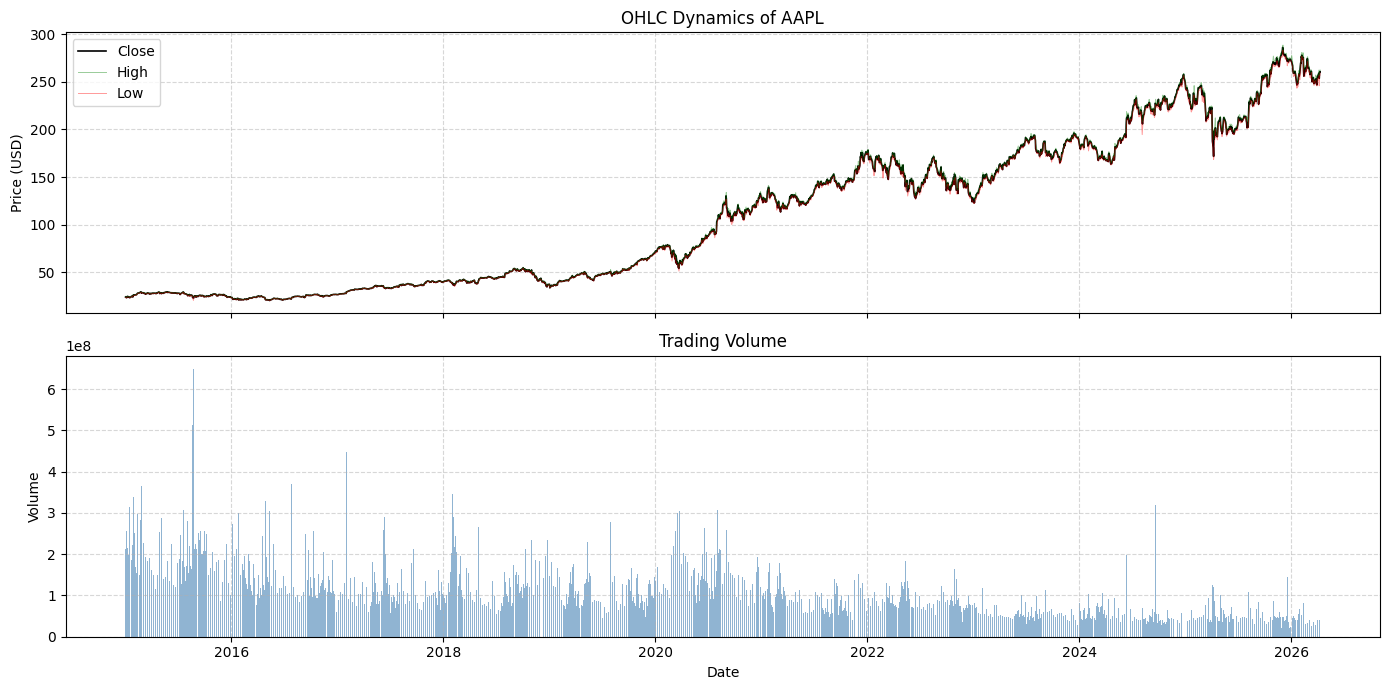

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

# 2-1. OHLC 가격 채널
axes[0].plot(mv_ts_data.index, mv_ts_data['Close'], label='Close', color='black', linewidth=1.2)
axes[0].plot(mv_ts_data.index, mv_ts_data['High'], label='High', color='green', alpha=0.4, linewidth=0.7)
axes[0].plot(mv_ts_data.index, mv_ts_data['Low'], label='Low', color='red', alpha=0.4, linewidth=0.7)
axes[0].set_title(f"OHLC Dynamics of {ticker_symbol}")
axes[0].set_ylabel("Price (USD)")
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.5)

# 2-2. Volume 채널 (Secondary Dynamic)
axes[1].bar(mv_ts_data.index, mv_ts_data['Volume'], color='steelblue', alpha=0.6, width=1.0)
axes[1].set_title("Trading Volume")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Volume")
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### 채널 간 상관관계 (Correlation Matrix)

OHLC는 구조적으로 강한 양의 상관관계를 가지며(가격 채널), Volume은 가격 채널과 상대적으로 독립적이다.

이러한 채널 간 이질성(Heterogeneity)은 CNN이 커널을 통해 채널 간 결합 표현(Joint Representation)을 학습할 여지를 제공한다.

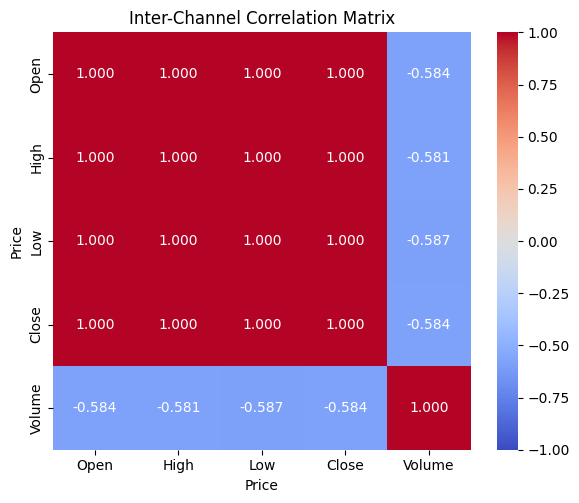

In [ ]:
import seaborn as sns

corr_matrix = mv_ts_data.corr()
plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.3f', square=True)
plt.title("Inter-Channel Correlation Matrix")
plt.tight_layout()
plt.show()

## 다변량 시퀀스 전처리 (Channel-wise Normalization 및 Look-back Window)

다변량 입력은 채널 간 스케일 편차가 매우 크므로(예: Close $\sim 10^2$, Volume $\sim 10^7$), **채널별 독립 정규화(Channel-wise Normalization)** 가 필수적이다.

$$x_{t, c}^{(norm)} = \frac{x_{t, c} - \min(\mathcal{X}^{(c)}_{train})}{\max(\mathcal{X}^{(c)}_{train}) - \min(\mathcal{X}^{(c)}_{train})}, \quad c \in \{O, H, L, C, V\}$$

스케일 차이를 정규화 없이 주입하면 Volume 채널의 그래디언트가 다른 채널을 압도하여 Optimization이 실패한다.

또한, Part 1과 동일하게 스케일러는 **오직 Training Set에서만 피팅**되어 Look-ahead Bias를 차단한다.

**Target 구성**: 슬라이딩 윈도우로 생성되는 입력 $X_t \in \mathbb{R}^{W \times C}$와 정답 $y_t$는 다음과 같이 정의된다.

$$X_t = [\mathbf{x}_{t-W}, \dots, \mathbf{x}_{t-1}], \quad y_t = x_{t, \text{Close}}$$

즉, 다변량 과거 시퀀스를 입력받아 **$t$ 시점의 Close Price 단일 스칼라**를 예측하는 Many-to-One 회귀 문제로 정식화된다.

In [ ]:
from sklearn.preprocessing import MinMaxScaler
from typing import Tuple


def preprocess_multivariate_time_series(
    df: pd.DataFrame,
    target_col: str = 'Close',
    train_ratio: float = 0.8,
    look_back: int = 60
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, MinMaxScaler, MinMaxScaler]:
    """
    다변량 시계열에 대해 Look-ahead Bias를 방지한 Channel-wise 정규화 및
    Sliding Window 기반 (N, W, C) 시퀀스를 생성한다.

    Target scaler는 예측값의 역변환(Inverse Transform)을 위해 별도 분리한다.
    """
    raw = df.values                                # shape: (T, C)
    target_idx = df.columns.get_loc(target_col)

    # 1. Chronological Split
    split = int(len(raw) * train_ratio)
    train_raw, test_raw = raw[:split], raw[split:]

    # 2. Channel-wise Normalization (Fit on Train only)
    feature_scaler = MinMaxScaler(feature_range=(0, 1))
    train_scaled = feature_scaler.fit_transform(train_raw)
    test_scaled = feature_scaler.transform(test_raw)

    # Target 역변환용 별도 스케일러 (단일 채널)
    target_scaler = MinMaxScaler(feature_range=(0, 1))
    target_scaler.fit(train_raw[:, target_idx].reshape(-1, 1))

    # 3. Sliding Window for Multivariate Input
    def create_mv_sequences(data: np.ndarray, window_size: int, t_idx: int):
        X, y = [], []
        for i in range(len(data) - window_size):
            X.append(data[i : i + window_size, :])        # (W, C)
            y.append(data[i + window_size, t_idx])        # scalar
        return np.array(X), np.array(y).reshape(-1, 1)

    X_train, y_train = create_mv_sequences(train_scaled, look_back, target_idx)
    X_test, y_test = create_mv_sequences(test_scaled, look_back, target_idx)

    return X_train, y_train, X_test, y_test, feature_scaler, target_scaler

### 전처리 실행 및 텐서 형상 검증

In [ ]:
# 실행 로직
WINDOW_SIZE = 60  # 60일 Look-back → 1일 예측

## 변경 가능한 파라미터 (예: 30, 90, 120)

X_train_seq, y_train_seq, X_test_seq, y_test_seq, feat_scaler, tgt_scaler = preprocess_multivariate_time_series(
    mv_ts_data,
    target_col='Close',
    train_ratio=0.8,
    look_back=WINDOW_SIZE
)

print(f"X_train shape: {X_train_seq.shape}")  # (N_train, 60, 5)
print(f"y_train shape: {y_train_seq.shape}")  # (N_train, 1)
print(f"X_test shape:  {X_test_seq.shape}")   # (N_test, 60, 5)
print(f"y_test shape:  {y_test_seq.shape}")   # (N_test, 1)
print(f"Input channels (C_in): {X_train_seq.shape[-1]}")

X_train shape: (2207, 60, 5)
y_train shape: (2207, 1)
X_test shape:  (507, 60, 5)
y_test shape:  (507, 1)
Input channels (C_in): 5


## PyTorch Dataset 및 DataLoader 구축

Part 1의 `TimeSeriesDataset` 추상을 다변량 입력에 그대로 적용한다. 텐서 차원이 $(N, W, C)$로 동일하게 유지되므로 구현 변경은 불필요하다.

단, CNN-LSTM의 1D Conv 연산은 입력 차원을 $(B, C, W)$로 요구하므로, 모델 `forward` 내부에서 `permute`를 통해 차원 재정렬을 수행한다. 데이터 파이프라인 단계에서 이를 수행하지 않는 이유는 LSTM 비교군과의 **데이터 인터페이스 일관성**을 유지하기 위함이다.

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader


class MultivariateTimeSeriesDataset(Dataset):
    """
    다변량 시계열 (N, W, C) 형태의 텐서를 래핑하는 Dataset.
    """
    def __init__(self, X: np.ndarray, y: np.ndarray):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self) -> int:
        return len(self.X)

    def __getitem__(self, idx: int) -> tuple:
        return self.X[idx], self.y[idx]

In [ ]:
BATCH_SIZE = 64

train_dataset = MultivariateTimeSeriesDataset(X_train_seq, y_train_seq)
test_dataset = MultivariateTimeSeriesDataset(X_test_seq, y_test_seq)

train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=True,
    pin_memory=True
)

test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    drop_last=False,
    pin_memory=True
)

In [ ]:
# DataLoader 텐서 형상 검증
sample_X, sample_y = next(iter(train_loader))
print(f"Batch X shape: {sample_X.shape}")  # Expected: (64, 60, 5) -> (B, W, C_in)
print(f"Batch y shape: {sample_y.shape}")  # Expected: (64, 1)

Batch X shape: torch.Size([64, 60, 5])
Batch y shape: torch.Size([64, 1])


## CNN-LSTM Hybrid 아키텍처 설계

CNN-LSTM은 2단계 특성 추상화 파이프라인으로 구성된다.

**Stage 1 — 1D Convolutional Feature Extractor**

입력 $X \in \mathbb{R}^{B \times W \times C_{in}}$을 PyTorch `Conv1d`의 요구 형식 $(B, C_{in}, W)$으로 `permute`한 뒤,

$$
Z^{(1)} = \text{ReLU}(\text{Conv1D}_{K, F}(X^{\top})), \quad Z^{(1)} \in \mathbb{R}^{B \times F \times W}
$$

여기서 $F$는 필터 수, $K$는 커널 크기(예: $K=3$, 인접 3일의 지역 패턴). `padding='same'` 방식으로 시퀀스 길이를 보존한다.

**Stage 2 — Temporal Downsampling via MaxPool**

$$
Z^{(2)} = \text{MaxPool1D}_{P}(Z^{(1)}) \in \mathbb{R}^{B \times F \times W/P}
$$

Pooling은 (1) 시퀀스 길이 축소에 따른 LSTM 연산량 감소, (2) 지역적 번역 불변성(Local Translation Invariance)을 제공한다.

**Stage 3 — LSTM Temporal Aggregator**

`permute`로 차원을 복원($B, W/P, F$)한 뒤 LSTM을 통과시킨다.

$$
h_{W/P} = \text{LSTM}(Z^{(2)\top}), \quad \hat{y} = W_{fc}\, h_{W/P} + b_{fc}
$$

**설계 시 유의사항**

- **Permute 일관성**: `Conv1d`는 $(B, C, W)$, `LSTM`(batch_first=True)은 $(B, W, C)$ 입력을 요구하므로 forward 내부에서 정확한 차원 재정렬이 필수적이다. 이 지점에서 발생하는 shape 오류가 CNN-LSTM 디버깅의 가장 흔한 실패 사례다.
- **Receptive Field 설계**: $K$와 Pooling 크기 $P$는 원본 시계열 상에서의 유효 수용 영역(Effective Receptive Field)을 결정한다. 예: $K=3, P=2$ → CNN 출력의 각 토큰은 원 시퀀스 $\sim 6$일을 요약.
- **Feature Dim 전달**: Conv의 출력 채널 수 $F$가 LSTM의 `input_size`가 된다. 파이프라인 구성 시 이 차원 매칭이 자동 검증되지 않으므로 명시적 기록이 필요하다.

In [ ]:
import torch
import torch.nn as nn


class CNNLSTMRegressor(nn.Module):
    """
    1D CNN - LSTM Hybrid 아키텍처 기반 다변량 시계열 회귀 모델.

    Stage 1: Conv1D가 채널 간 지역적 상호작용과 단기 패턴을 추출.
    Stage 2: MaxPool1D로 시퀀스 축소 및 Local Translation Invariance 확보.
    Stage 3: LSTM이 고수준 특성 시퀀스의 장기 의존성을 모델링.
    """
    def __init__(
        self,
        input_channels: int = 5,     # OHLCV
        conv_filters: int = 32,      # F
        kernel_size: int = 3,        # K
        pool_size: int = 2,          # P
        hidden_size: int = 64,
        num_layers: int = 2,
        dropout: float = 0.2,
    ):
        super().__init__()

        # Stage 1: Convolutional Feature Extractor
        # padding=(K-1)//2 → 시퀀스 길이 보존 ('same' padding)
        self.conv1 = nn.Conv1d(
            in_channels=input_channels,
            out_channels=conv_filters,
            kernel_size=kernel_size,
            padding=(kernel_size - 1) // 2
        )
        self.relu = nn.ReLU()

        # Stage 2: Temporal Downsampling
        self.pool = nn.MaxPool1d(kernel_size=pool_size)

        # Stage 3: Temporal Aggregator
        self.lstm = nn.LSTM(
            input_size=conv_filters,    # Conv 출력 채널 = LSTM 입력 특성
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )

        # Regression Head
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x: (B, W, C_in)     — DataLoader 출력 형식
        Returns:
            (B, 1)              — t+1 Close 예측값
        """
        # (B, W, C_in) → (B, C_in, W) : Conv1d 입력 규격
        x = x.permute(0, 2, 1)

        # Stage 1: (B, C_in, W) → (B, F, W)
        z = self.relu(self.conv1(x))

        # Stage 2: (B, F, W) → (B, F, W/P)
        z = self.pool(z)

        # (B, F, W/P) → (B, W/P, F) : LSTM 입력 규격
        z = z.permute(0, 2, 1)

        # Stage 3: LSTM → (B, W/P, H_dim)
        out, _ = self.lstm(z)

        # Many-to-One: 마지막 타임스텝의 Hidden State
        last_hidden = out[:, -1, :]      # (B, H_dim)

        return self.fc(last_hidden)      # (B, 1)

### 아키텍처 구조 및 파라미터 수 검증

In [ ]:
# 구조 검증
_dummy_model = CNNLSTMRegressor(
    input_channels=5, conv_filters=32, kernel_size=3,
    pool_size=2, hidden_size=64, num_layers=2
)
_dummy_x = torch.randn(4, WINDOW_SIZE, 5)
_dummy_y = _dummy_model(_dummy_x)

print(f"Input shape:  {tuple(_dummy_x.shape)}")
print(f"Output shape: {tuple(_dummy_y.shape)}")
print(f"Trainable params: {sum(p.numel() for p in _dummy_model.parameters() if p.requires_grad):,}")
print(_dummy_model)

Input shape:  (4, 60, 5)
Output shape: (4, 1)
Trainable params: 58,945
CNNLSTMRegressor(
  (conv1): Conv1d(5, 32, kernel_size=(3,), stride=(1,), padding=(1,))
  (relu): ReLU()
  (pool): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (lstm): LSTM(32, 64, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)


## 학습 루프 구현 및 $\mathcal{L}_{MSE}$ 최적화 (LSTM vs. CNN-LSTM 비교 분석)

Part 1의 비교 실험(RNN vs. LSTM)과 동형의 구조로, **공정한 비교군**인 **Multivariate LSTM** 을 베이스라인으로 설정한다.

입력 채널 수($C_{in}=5$)를 제외한 모든 하이퍼파라미터(Hidden Size, Layers, Dropout, Optimizer, LR, Epochs)를 동일하게 유지함으로써, **CNN 블록의 순수 기여도(Incremental Contribution)** 를 분리 측정한다.

예상되는 관측 결과:
1. CNN-LSTM은 동일 학습량 대비 빠른 수렴 (지역 패턴의 선행 추출로 인해 LSTM 학습 부담 경감)
2. Test Set MSE의 미세한 개선 또는 유의미한 개선 (채널 간 상호작용 포착 효과)
3. 단, 금융 시계열의 높은 노이즈 및 Weak Signal 특성상 개선 폭이 크지 않을 수 있음 (현실적 한계)

### Multivariate LSTM 아키텍처 정의 (비교군)

In [ ]:
class LSTMRegressorMV(nn.Module):
    """
    CNN 블록 없이 다변량 입력을 LSTM에 직접 주입하는 비교군 모델.
    Part 1의 LSTMRegressor와 동일 구조이며, input_size만 5로 확장.
    """
    def __init__(self, input_size: int = 5, hidden_size: int = 64, num_layers: int = 2, dropout: float = 0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        out, _ = self.lstm(x)
        last_hidden = out[:, -1, :]
        return self.fc(last_hidden)

### 하드웨어 가속기 설정 및 모델 인스턴스화

In [ ]:
import torch.optim as optim

device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')
print(f"Target execution device: {device}")

# 동일 하이퍼파라미터로 두 모델 초기화
cnn_lstm_model = CNNLSTMRegressor(
    input_channels=5, conv_filters=32, kernel_size=3,
    pool_size=2, hidden_size=64, num_layers=2, dropout=0.2
).to(device)  ## 모델 구조는 여기서 변경 가능

lstm_mv_model = LSTMRegressorMV(
    input_size=5, hidden_size=64, num_layers=2, dropout=0.2
).to(device)

criterion = nn.MSELoss()
cnn_lstm_optimizer = optim.Adam(cnn_lstm_model.parameters(), lr=1e-3)  ## training 파라미터는 여기서 변경 가능
lstm_mv_optimizer = optim.Adam(lstm_mv_model.parameters(), lr=1e-3)

# 파라미터 수 비교
n_cnn_lstm = sum(p.numel() for p in cnn_lstm_model.parameters() if p.requires_grad)
n_lstm_mv = sum(p.numel() for p in lstm_mv_model.parameters() if p.requires_grad)
print(f"CNN-LSTM params: {n_cnn_lstm:,}")
print(f"LSTM-MV  params: {n_lstm_mv:,}")

Target execution device: cuda
CNN-LSTM params: 58,945
LSTM-MV  params: 51,521


### 범용 학습 및 검증 파이프라인 (Part 1 재사용)

In [ ]:
def train_and_evaluate(
    model: nn.Module,
    optimizer: optim.Optimizer,
    train_loader: DataLoader,
    test_loader: DataLoader,
    epochs: int = 50
) -> dict:
    history = {'train_loss': [], 'test_loss': []}

    for epoch in range(epochs):
        # Training Phase
        model.train()
        train_loss_accum = 0.0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            optimizer.zero_grad()
            predictions = model(X_batch)
            loss = criterion(predictions, y_batch)
            loss.backward()

            # Gradient Clipping (Exploding Gradient 억제)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            train_loss_accum += loss.item() * X_batch.size(0)

        epoch_train_loss = train_loss_accum / len(train_loader.dataset)
        history['train_loss'].append(epoch_train_loss)

        # Validation Phase
        model.eval()
        test_loss_accum = 0.0
        with torch.no_grad():
            for X_batch, y_batch in test_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                predictions = model(X_batch)
                loss = criterion(predictions, y_batch)
                test_loss_accum += loss.item() * X_batch.size(0)

        epoch_test_loss = test_loss_accum / len(test_loader.dataset)
        history['test_loss'].append(epoch_test_loss)

        if (epoch + 1) % 10 == 0:
            print(f"Epoch [{epoch+1}/{epochs}] | Train loss: {epoch_train_loss:.6f} | Test loss: {epoch_test_loss:.6f}")

    return history

### 모델 학습 실행

In [ ]:
EPOCHS = 50

print("--- Training CNN-LSTM Model ---")
cnn_lstm_history = train_and_evaluate(cnn_lstm_model, cnn_lstm_optimizer, train_loader, test_loader, epochs=EPOCHS)

print("\n--- Training LSTM (Multivariate) Baseline ---")
lstm_mv_history = train_and_evaluate(lstm_mv_model, lstm_mv_optimizer, train_loader, test_loader, epochs=EPOCHS)

--- Training CNN-LSTM Model ---
Epoch [10/50] | Train loss: 0.000748 | Test loss: 0.014579
Epoch [20/50] | Train loss: 0.000540 | Test loss: 0.003282
Epoch [30/50] | Train loss: 0.000428 | Test loss: 0.006003
Epoch [40/50] | Train loss: 0.000443 | Test loss: 0.002594
Epoch [50/50] | Train loss: 0.000354 | Test loss: 0.003158

--- Training LSTM (Multivariate) Baseline ---
Epoch [10/50] | Train loss: 0.000642 | Test loss: 0.018203
Epoch [20/50] | Train loss: 0.000589 | Test loss: 0.012343
Epoch [30/50] | Train loss: 0.000486 | Test loss: 0.006220
Epoch [40/50] | Train loss: 0.000427 | Test loss: 0.005354
Epoch [50/50] | Train loss: 0.000395 | Test loss: 0.005186


### 최적화 과정(Loss) 및 예측 결과 시각화

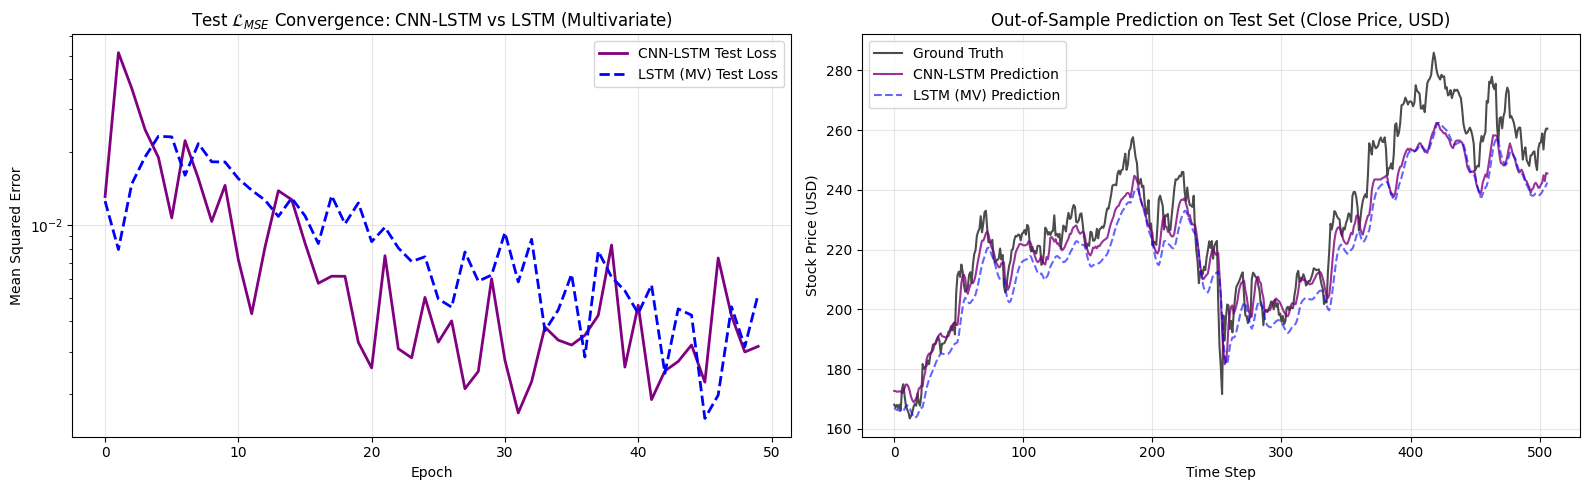

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 6-1. Loss Convergence Comparison
axes[0].plot(cnn_lstm_history['test_loss'], label='CNN-LSTM Test Loss', color='purple', linewidth=2)
axes[0].plot(lstm_mv_history['test_loss'], label='LSTM (MV) Test Loss', color='blue', linestyle='--', linewidth=2)
axes[0].set_title(r"Test $\mathcal{L}_{MSE}$ Convergence: CNN-LSTM vs LSTM (Multivariate)")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Mean Squared Error")
axes[0].set_yscale('log')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 6-2. Test Set Prediction (Inverse Transform to USD scale)
def get_predictions(model: nn.Module, loader: DataLoader) -> np.ndarray:
    model.eval()
    preds = []
    with torch.no_grad():
        for X_batch, _ in loader:
            X_batch = X_batch.to(device)
            preds.append(model(X_batch).cpu().numpy())
    return np.concatenate(preds, axis=0)

cnn_lstm_preds_scaled = get_predictions(cnn_lstm_model, test_loader)
lstm_mv_preds_scaled = get_predictions(lstm_mv_model, test_loader)

# Target 전용 scaler로 역변환 (Close Price 복원)
cnn_lstm_preds_real = tgt_scaler.inverse_transform(cnn_lstm_preds_scaled)
lstm_mv_preds_real = tgt_scaler.inverse_transform(lstm_mv_preds_scaled)
actual_real = tgt_scaler.inverse_transform(y_test_seq)

axes[1].plot(actual_real, label='Ground Truth', color='black', alpha=0.7)
axes[1].plot(cnn_lstm_preds_real, label='CNN-LSTM Prediction', color='purple', alpha=0.8)
axes[1].plot(lstm_mv_preds_real, label='LSTM (MV) Prediction', color='blue', alpha=0.6, linestyle='--')
axes[1].set_title("Out-of-Sample Prediction on Test Set (Close Price, USD)")
axes[1].set_xlabel("Time Step")
axes[1].set_ylabel("Stock Price (USD)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 정량 지표 비교 (RMSE, MAE)

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

def report_metrics(name: str, y_true: np.ndarray, y_pred: np.ndarray):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    print(f"[{name:12s}]  RMSE: {rmse:7.3f} USD   |   MAE: {mae:7.3f} USD")

print("=== Out-of-Sample Performance (Test Set, Real Scale) ===")
report_metrics("CNN-LSTM",  actual_real, cnn_lstm_preds_real)
report_metrics("LSTM (MV)", actual_real, lstm_mv_preds_real)

=== Out-of-Sample Performance (Test Set, Real Scale) ===
[CNN-LSTM    ]  RMSE:   9.862 USD   |   MAE:   7.773 USD
[LSTM (MV)   ]  RMSE:  12.637 USD   |   MAE:  10.917 USD


## 결론 및 확장 실험 제안

**주요 관찰 포인트**

1. CNN 블록의 존재 유무에 따른 Test Loss 수렴 속도 차이 관찰.
2. Inverse Transform 후 실제 USD 스케일에서의 RMSE/MAE 비교를 통한 실용적 성능 평가.
3. 금융 시계열은 Signal-to-Noise Ratio가 극히 낮아 단일 실험(Single-seed Run)의 결과를 일반화하기 어려움 → 복수 시드 평균 검증 권장.

**확장 실험 제안**

- **Receptive Field 민감도 분석**: $K \in \{3, 5, 7\}$, $P \in \{2, 3\}$ Grid에 대한 Ablation.
- **Depth 확장**: Conv → BatchNorm → ReLU → Pool 블록을 2~3회 스택하여 Hierarchical Feature Extraction 강화.
- **Channel-wise Attention**: Conv 출력에 Squeeze-and-Excitation 블록 삽입으로 채널 중요도 재가중.
- **Bidirectional LSTM**: 양방향 문맥 활용 (단, 시계열 예측 과제에서는 Look-ahead Bias 검증 필수).
- **Residual Connection**: CNN 경로와 원본 LSTM 경로를 병렬 구성 후 Late Fusion.